# Projeto 1 — Benchmark de Algoritmos de Ordenação

**Aluno(a):** Mateus de Pasquali da Silva | RA: 10376389

**Disciplina:** Algoritmos e Programação

## Objetivo
Este notebook implementa e compara os algoritmos de ordenação **Bolha**, **Seleção**, **Inserção**, **MergeSort** e **QuickSort** em vetores de tamanhos **1.000**, **10.000** e **100.000**, considerando três cenários de entrada:

1. valores aleatórios  
2. valores em ordem crescente  
3. valores em ordem decrescente  

Além do tempo de execução, o notebook também registra informações sobre **uso de memória** e **clock do processador**, quando disponíveis no ambiente.

Para reduzir oscilações do sistema operacional, do interpretador e do próprio ambiente de execução, **cada experimento é repetido 5 vezes** para cada combinação de **tamanho do vetor**, **tipo de vetor** e **algoritmo**. Ao final, o notebook:

- armazena o resultado de **cada tentativa individual**  
- calcula o **tempo médio** por cenário  
- gera tabelas e gráficos comparativos  
- produz um texto-base para o relatório analítico


In [1]:
!pip install numpy pandas matplotlib psutil ipython plotly scipy nbconvert notebook


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports principais
import os
import sys
import math
import time
import tracemalloc
import platform
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psutil
except ImportError:
    psutil = None

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_DISPONIVEL = True
except ImportError:
    px = None
    go = None
    PLOTLY_DISPONIVEL = False

try:
    from scipy import stats as scipy_stats
    SCIPY_DISPONIVEL = True
except ImportError:
    scipy_stats = None
    SCIPY_DISPONIVEL = False

from IPython.display import display, Markdown

sys.setrecursionlimit(300_000)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

print(f"Plotly disponível: {PLOTLY_DISPONIVEL}")
print(f"SciPy disponível: {SCIPY_DISPONIVEL}")


Plotly disponível: True
SciPy disponível: True


## 1. Configurações do experimento

Nesta seção são definidos os tamanhos dos vetores, o número de repetições e o diretório de saída para salvar os resultados e os gráficos.

Neste notebook, o valor padrão de repetições foi configurado para **3 execuções por cenário**, de modo que cada combinação entre tamanho, tipo de vetor e algoritmo tenha um histórico completo das tentativas e um resumo com base no **tempo médio** obtido.


In [3]:
# =========================
# CONFIGURAÇÕES DO TESTE
# =========================

SEED = 42
TAMANHOS = [1_000, 10_000, 100_000]
TIPOS_VETOR = ["aleatorio", "crescente", "decrescente"]

# Cada experimento será repetido 3 vezes para reduzir oscilações do ambiente.
REPETICOES = 3

# Deixe True para atender integralmente ao enunciado.
# Se quiser apenas um teste exploratório inicial, altere para False.
EXECUTAR_TESTE_COMPLETO = True

# Pasta solicitada pelo usuário para salvar os resultados no Windows.
OUTPUT_DIR_USUARIO = Path(
    r"C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados"
)

# Em ambientes que não são Windows, usa uma pasta local para não quebrar a execução.
if os.name == "nt":
    OUTPUT_DIR = OUTPUT_DIR_USUARIO
else:
    OUTPUT_DIR = Path("saida_benchmark")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configurações carregadas com sucesso.")
print(f"Tamanhos: {TAMANHOS}")
print(f"Tipos de vetor: {TIPOS_VETOR}")
print(f"Repetições por cenário: {REPETICOES}")
print(f"Teste completo: {EXECUTAR_TESTE_COMPLETO}")
print(f"Pasta configurada pelo usuário: {OUTPUT_DIR_USUARIO}")
print(f"Pasta ativa para esta execução: {OUTPUT_DIR.resolve()}")


Configurações carregadas com sucesso.
Tamanhos: [1000, 10000, 100000]
Tipos de vetor: ['aleatorio', 'crescente', 'decrescente']
Repetições por cenário: 3
Teste completo: True
Pasta configurada pelo usuário: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados
Pasta ativa para esta execução: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados


## 2. Identificação do equipamento

A célula abaixo registra informações da máquina utilizada no experimento, como sistema operacional, processador, quantidade de núcleos, memória RAM e frequência do processador, quando disponível.

In [4]:
def coletar_info_maquina():
    info = {
        "Sistema Operacional": platform.platform(),
        "Arquitetura": platform.machine(),
        "Processador": platform.processor() or "Não identificado pelo sistema",
        "Python": platform.python_version(),
        "Núcleos físicos": psutil.cpu_count(logical=False) if psutil else "N/D",
        "Núcleos lógicos": psutil.cpu_count(logical=True) if psutil else "N/D",
        "RAM total (GB)": round(psutil.virtual_memory().total / (1024**3), 2) if psutil else "N/D",
    }

    if psutil and psutil.cpu_freq():
        info["Clock atual (MHz)"] = round(psutil.cpu_freq().current, 2)
        info["Clock mínimo (MHz)"] = round(psutil.cpu_freq().min, 2)
        info["Clock máximo (MHz)"] = round(psutil.cpu_freq().max, 2)
    else:
        info["Clock atual (MHz)"] = "N/D"
        info["Clock mínimo (MHz)"] = "N/D"
        info["Clock máximo (MHz)"] = "N/D"

    return pd.DataFrame(info.items(), columns=["Métrica", "Valor"])

df_maquina = coletar_info_maquina()
display(df_maquina)

,Métrica,Valor
0,Sistema Operacional,Windows-11-10.0.26200-SP0
1,Arquitetura,AMD64
2,Processador,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD"
3,Python,3.14.3
4,Núcleos físicos,8
5,Núcleos lógicos,16
6,RAM total (GB),15.92
7,Clock atual (MHz),3801.0
8,Clock mínimo (MHz),0.0
9,Clock máximo (MHz),3801.0


## 3. Geração da massa de dados

A massa de dados segue exatamente o enunciado:

- vetores aleatórios com tamanhos 1.000, 10.000 e 100.000  
- vetores em ordem crescente derivados dos vetores aleatórios  
- vetores em ordem decrescente derivados dos vetores aleatórios  

Desse modo, os três cenários partem da mesma base de valores para cada tamanho.

In [5]:
def gerar_vetores_aleatorios(tamanhos, seed=42, minimo=0, maximo=1_000_000):
    rng = np.random.default_rng(seed)
    vetores = {}
    for n in tamanhos:
        vetores[n] = rng.integers(minimo, maximo, size=n).tolist()
    return vetores

def gerar_variacoes_ordenadas(vetores_aleatorios):
    base = {}
    for n, vetor in vetores_aleatorios.items():
        crescente = sorted(vetor)
        decrescente = crescente[::-1]
        base[n] = {
            "aleatorio": vetor.copy(),
            "crescente": crescente,
            "decrescente": decrescente,
        }
    return base

vetores_aleatorios = gerar_vetores_aleatorios(TAMANHOS, seed=SEED)
base_vetores = gerar_variacoes_ordenadas(vetores_aleatorios)

# Exemplo de inspeção
for tamanho in TAMANHOS:
    print(f"\nTamanho {tamanho}:")
    for tipo in TIPOS_VETOR:
        amostra = base_vetores[tamanho][tipo][:10]
        print(f"  {tipo:12s} -> {amostra}")


Tamanho 1000:
  aleatorio    -> [89250, 773956, 654571, 438878, 433015, 858597, 85945, 697368, 201469, 94177]
  crescente    -> [4379, 4890, 5307, 5429, 5473, 6511, 7075, 7362, 7853, 9916]
  decrescente  -> [999104, 998027, 997034, 996659, 996106, 994581, 992665, 992375, 991382, 989683]

Tamanho 10000:
  aleatorio    -> [808300, 736705, 558317, 886402, 128267, 921057, 850226, 503632, 733391, 520275]
  crescente    -> [0, 314, 415, 518, 568, 642, 824, 926, 989, 992]
  decrescente  -> [999959, 999812, 999765, 999714, 999485, 999460, 999421, 999408, 999390, 999219]

Tamanho 100000:
  aleatorio    -> [849082, 171204, 635273, 506826, 611925, 112716, 466553, 626048, 340941, 874899]
  crescente    -> [3, 13, 18, 19, 20, 27, 42, 47, 50, 57]
  decrescente  -> [999993, 999989, 999982, 999977, 999974, 999960, 999957, 999956, 999952, 999948]


In [6]:
# Validação da montategm dos vetores 
from IPython.display import display
import pandas as pd

tamanho_escolhido = 1000
tipo_escolhido = "crescente"

df_vetor = pd.DataFrame({
    "indice": range(len(base_vetores[tamanho_escolhido][tipo_escolhido])),
    "valor": base_vetores[tamanho_escolhido][tipo_escolhido]
})

display(df_vetor)

,indice,valor
0,0,4379
1,1,4890
2,2,5307
3,3,5429
4,4,5473
...,...,...
995,995,996106
996,996,996659
997,997,997034
998,998,998027


## 4. Implementação dos algoritmos de ordenação

Foram implementados os seguintes métodos:

- **Bolha melhorado**
- **Seleção**
- **Inserção**
- **MergeSort**
- **QuickSort** (particionamento de Hoare com pivô central)

A escolha do pivô central no QuickSort reduz a chance de degradação severa em vetores já ordenados, tornando a implementação mais próxima de uma abordagem prática.

## Explicação da lógica de cada algoritmo de ordenação

Nesta etapa do projeto, foram implementados cinco algoritmos clássicos de ordenação: **Bolha**, **Seleção**, **Inserção**, **MergeSort** e **QuickSort**. A seguir, apresenta-se a lógica de funcionamento de cada método e a forma como foram estruturados no código.

### 1. Bolha (Bubble Sort)

O algoritmo de **Bolha** realiza a ordenação por meio de comparações sucessivas entre elementos adjacentes do vetor. Sempre que dois elementos consecutivos estão em ordem incorreta, eles são trocados de posição. Ao final de cada passagem completa pelo vetor, o maior elemento da parte não ordenada “sobe” para sua posição correta, o que justifica o nome do algoritmo.

Na implementação, foi utilizada a lógica tradicional com dois laços: um laço externo para controlar o número de passagens e um laço interno para comparar os elementos vizinhos. Quando necessário, ocorre a troca dos valores. Em versões melhoradas, pode-se usar uma variável de controle para interromper o processo caso nenhuma troca seja realizada em uma passagem, indicando que o vetor já está ordenado.

### 2. Seleção (Selection Sort)

O algoritmo de **Seleção** funciona identificando, a cada etapa, o menor elemento da parte ainda não ordenada do vetor e posicionando-o no início dessa região. Assim, a cada iteração, cresce a porção ordenada à esquerda do vetor.

Na implementação, para cada posição `i`, percorre-se o restante do vetor em busca do menor valor. Ao final da busca, o menor elemento encontrado é trocado com o elemento da posição atual. Dessa forma, o algoritmo organiza o vetor de maneira progressiva, fixando um elemento em sua posição correta a cada passagem.

### 3. Inserção (Insertion Sort)

O algoritmo de **Inserção** ordena o vetor de forma semelhante à maneira como uma pessoa organiza cartas na mão. Parte-se do pressuposto de que a primeira posição já está ordenada, e cada novo elemento é inserido na posição correta dentro da parte já ordenada do vetor.

Na implementação, o algoritmo percorre o vetor a partir do segundo elemento. Para cada valor, ele armazena temporariamente esse elemento e desloca para a direita todos os valores maiores que ele, até encontrar a posição correta de inserção. Em seguida, o elemento é colocado no local adequado. Esse método tende a ter bom desempenho em vetores pequenos ou quase ordenados.

### 4. MergeSort

O **MergeSort** é um algoritmo baseado na estratégia de **divisão e conquista**. Sua lógica consiste em dividir recursivamente o vetor em duas metades até que cada subvetor tenha apenas um elemento. Em seguida, esses subvetores são recombinados de forma ordenada, produzindo gradualmente um vetor final ordenado.

Na implementação, o algoritmo foi estruturado com uma função recursiva. Primeiro, o vetor é dividido em duas partes. Depois, a própria função é chamada para ordenar cada metade separadamente. Por fim, ocorre a etapa de intercalação (**merge**), em que dois subvetores ordenados são comparados elemento a elemento e reunidos em ordem crescente. Esse processo garante eficiência mais estável em comparação aos algoritmos quadráticos.

### 5. QuickSort

O **QuickSort** também utiliza a estratégia de **divisão e conquista**, mas sua abordagem é diferente da do MergeSort. O algoritmo escolhe um elemento chamado **pivô** e reorganiza o vetor de modo que os elementos menores que o pivô fiquem à esquerda e os maiores fiquem à direita. Após esse particionamento, o mesmo processo é aplicado recursivamente às duas partes resultantes.

Na implementação, foi definida uma rotina de particionamento responsável por posicionar o pivô em sua posição correta dentro do vetor. Após isso, o algoritmo chama recursivamente a ordenação para a parte esquerda e para a parte direita do pivô. O desempenho do QuickSort depende bastante da escolha do pivô: quando a partição é equilibrada, o algoritmo tende a ser muito eficiente; porém, em casos desfavoráveis, seu desempenho pode piorar significativamente.

## Estrutura geral de montagem no código

Todos os algoritmos foram implementados em funções separadas, permitindo sua aplicação sobre os diferentes vetores gerados no experimento. Para garantir justiça na comparação, cada algoritmo recebeu uma **cópia do vetor original**, evitando que um método alterasse os dados que seriam usados pelos demais. Essa organização permitiu medir o tempo e, quando possível, o uso de memória de forma padronizada para todos os métodos, em diferentes tamanhos e tipos de entrada.

De forma geral, os algoritmos **Bolha**, **Seleção** e **Inserção** apresentam complexidade assintótica quadrática em muitos cenários, o que tende a elevar significativamente o tempo de execução em vetores grandes. Já os algoritmos **MergeSort** e **QuickSort** possuem comportamento assintótico mais eficiente na maior parte dos casos, justificando seu melhor desempenho prático em massas de dados mais extensas.

In [7]:
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        trocou = False
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                trocou = True
        if not trocou:
            break
    return arr

def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        indice_min = i
        for j in range(i + 1, n):
            if arr[j] < arr[indice_min]:
                indice_min = j
        arr[i], arr[indice_min] = arr[indice_min], arr[i]
    return arr

def insertion_sort(arr):
    for i in range(1, len(arr)):
        chave = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > chave:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = chave
    return arr

def merge(esquerda, direita):
    resultado = []
    i = j = 0

    while i < len(esquerda) and j < len(direita):
        if esquerda[i] <= direita[j]:
            resultado.append(esquerda[i])
            i += 1
        else:
            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])
    return resultado

def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    meio = len(arr) // 2
    esquerda = merge_sort(arr[:meio])
    direita = merge_sort(arr[meio:])
    return merge(esquerda, direita)

def quick_sort(arr):
    def _partition(a, low, high):
        pivot = a[(low + high) // 2]
        i = low - 1
        j = high + 1
        while True:
            i += 1
            while a[i] < pivot:
                i += 1
            j -= 1
            while a[j] > pivot:
                j -= 1
            if i >= j:
                return j
            a[i], a[j] = a[j], a[i]

    def _quick_sort(a, low, high):
        if low < high:
            p = _partition(a, low, high)
            _quick_sort(a, low, p)
            _quick_sort(a, p + 1, high)

    _quick_sort(arr, 0, len(arr) - 1)
    return arr

ALGORITMOS = {
    "Bolha": bubble_sort,
    "Seleção": selection_sort,
    "Inserção": insertion_sort,
    "MergeSort": merge_sort,
    "QuickSort": quick_sort,
}

ALGORITMOS_QUADRATICOS = {"Bolha", "Seleção", "Inserção"}

## 5. Funções auxiliares de benchmark

A medição considera:

- **tempo de execução** em segundos  
- **memória de pico** em KiB via `tracemalloc`  
- **clock atual do processador** em MHz, quando disponível  

Também é realizada uma checagem para garantir que o vetor final realmente ficou ordenado.

A função principal desta seção retorna dois níveis de informação:

1. **resultado detalhado por tentativa**, identificando execução 1, 2, 3, 4 e 5  
2. **resultado resumido por cenário**, com destaque para o **tempo médio**, além de mediana, mínimo e máximo


In [8]:
def esta_ordenado(vetor):
    return all(vetor[i] <= vetor[i + 1] for i in range(len(vetor) - 1))

def medir_execucao(funcao_ordenacao, vetor_base, repeticoes=1):
    tempos = []
    picos_memoria = []
    clocks = []
    validacoes = []
    tentativas = []

    for execucao in range(1, repeticoes + 1):
        vetor = vetor_base.copy()

        clock_atual = np.nan
        if psutil and psutil.cpu_freq():
            freq = psutil.cpu_freq()
            if freq is not None:
                clock_atual = round(freq.current, 2)

        tracemalloc.start()
        inicio = time.perf_counter()

        resultado = funcao_ordenacao(vetor)

        fim = time.perf_counter()
        memoria_atual, pico_memoria = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        vetor_ordenado = resultado if resultado is not None else vetor
        tempo_execucao = fim - inicio
        memoria_pico_kib = pico_memoria / 1024
        ordenado = esta_ordenado(vetor_ordenado)

        tempos.append(tempo_execucao)
        picos_memoria.append(memoria_pico_kib)
        clocks.append(clock_atual)
        validacoes.append(ordenado)

        tentativas.append({
            "Execução": execucao,
            "Tempo (s)": float(tempo_execucao),
            "Memória pico (KiB)": float(memoria_pico_kib),
            "Clock (MHz)": float(clock_atual) if not np.isnan(clock_atual) else np.nan,
            "Ordenado corretamente": ordenado,
        })

    resumo = {
        "Tempo médio (s)": float(np.mean(tempos)),
        "Tempo mediano (s)": float(np.median(tempos)),
        "Tempo mínimo (s)": float(np.min(tempos)),
        "Tempo máximo (s)": float(np.max(tempos)),
        "Memória pico média (KiB)": float(np.mean(picos_memoria)),
        "Clock médio (MHz)": float(np.nanmean(clocks)) if not np.isnan(clocks).all() else np.nan,
        "Ordenado corretamente": all(validacoes),
    }

    return resumo, tentativas


## 6. Execução dos experimentos

Esta é a célula principal do benchmark.  
Ela executa todos os algoritmos em todos os tamanhos e em todos os tipos de vetor definidos no enunciado.

Para cada cenário, o notebook:

- executa o algoritmo **3 vezes**
- registra cada tentativa individual
- calcula o **tempo médio** usado nas comparações
- salva duas bases:
  - uma base **detalhada** com todas as tentativas
  - uma base **resumida** com as métricas consolidadas por cenário


In [9]:
resultados_resumo = []
resultados_tentativas = []

for tamanho in TAMANHOS:
    for tipo in TIPOS_VETOR:
        vetor_base = base_vetores[tamanho][tipo]
        print(f"\nExecutando cenário -> tamanho={tamanho:,} | tipo={tipo}")

        for nome_algoritmo, funcao_algoritmo in ALGORITMOS.items():
            if (not EXECUTAR_TESTE_COMPLETO) and (tamanho == 100_000) and (nome_algoritmo in ALGORITMOS_QUADRATICOS):
                print(f"  - {nome_algoritmo} [PULADO NO MODO EXPLORATÓRIO]")
                continue

            print(f"  - {nome_algoritmo}")
            metricas_resumo, tentativas = medir_execucao(
                funcao_algoritmo,
                vetor_base,
                repeticoes=REPETICOES
            )

            resultados_resumo.append({
                "Tamanho": tamanho,
                "Tipo de vetor": tipo,
                "Algoritmo": nome_algoritmo,
                **metricas_resumo
            })

            for tentativa in tentativas:
                resultados_tentativas.append({
                    "Tamanho": tamanho,
                    "Tipo de vetor": tipo,
                    "Algoritmo": nome_algoritmo,
                    **tentativa
                })

df_resultados = pd.DataFrame(resultados_resumo)
df_resultados = df_resultados.sort_values(
    ["Tamanho", "Tipo de vetor", "Tempo médio (s)"]
).reset_index(drop=True)

df_tentativas = pd.DataFrame(resultados_tentativas)
df_tentativas = df_tentativas.sort_values(
    ["Tamanho", "Tipo de vetor", "Algoritmo", "Execução"]
).reset_index(drop=True)

csv_resumo_path = OUTPUT_DIR / "resultados_benchmark_ordenacao_resumo.csv"
csv_tentativas_path = OUTPUT_DIR / "resultados_benchmark_ordenacao_tentativas.csv"

df_resultados.to_csv(csv_resumo_path, index=False, encoding="utf-8-sig")
df_tentativas.to_csv(csv_tentativas_path, index=False, encoding="utf-8-sig")

display(Markdown("### Resultados resumidos (média por cenário)"))
display(df_resultados)

display(Markdown("### Resultados detalhados por tentativa"))
display(df_tentativas.head(20))

print(f"\nArquivo CSV resumido salvo em: {csv_resumo_path.resolve()}")
print(f"Arquivo CSV detalhado salvo em: {csv_tentativas_path.resolve()}")



Executando cenário -> tamanho=1,000 | tipo=aleatorio
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=1,000 | tipo=crescente
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=1,000 | tipo=decrescente
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=10,000 | tipo=aleatorio
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=10,000 | tipo=crescente
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=10,000 | tipo=decrescente
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=100,000 | tipo=aleatorio
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=100,000 | tipo=crescente
  - Bolha
  - Seleção
  - Inserção
  - MergeSort
  - QuickSort

Executando cenário -> tamanho=100,000 | tipo=decresc

### Resultados resumidos (média por cenário)

,Tamanho,Tipo de vetor,Algoritmo,Tempo médio (s),Tempo mediano (s),Tempo mínimo (s),Tempo máximo (s),Memória pico média (KiB),Clock médio (MHz),Ordenado corretamente
0,1000,aleatorio,QuickSort,0.000953,0.000936,0.000932,0.000993,0.414062,3801.0,True
1,1000,aleatorio,MergeSort,0.003431,0.003150,0.003140,0.004004,17.026042,3801.0,True
2,1000,aleatorio,Inserção,0.020311,0.020140,0.019134,0.021659,1.385742,3801.0,True
3,1000,aleatorio,Seleção,0.020431,0.020550,0.020075,0.020667,0.007812,3801.0,True
4,1000,aleatorio,Bolha,0.043483,0.043767,0.042106,0.044574,0.277018,3801.0,True
5,1000,crescente,Bolha,0.000061,0.000059,0.000057,0.000067,0.007812,3801.0,True
6,1000,crescente,Inserção,0.000100,0.000100,0.000100,0.000101,0.007812,3801.0,True
7,1000,crescente,QuickSort,0.000695,0.000693,0.000692,0.000699,0.414062,3801.0,True
8,1000,crescente,MergeSort,0.002613,0.002598,0.002594,0.002648,19.531250,3801.0,True
9,1000,crescente,Seleção,0.022346,0.020673,0.020330,0.026034,0.007812,3801.0,True


### Resultados detalhados por tentativa

,Tamanho,Tipo de vetor,Algoritmo,Execução,Tempo (s),Memória pico (KiB),Clock (MHz),Ordenado corretamente
0,1000,aleatorio,Bolha,1,0.044574,0.023438,3801.0,True
1,1000,aleatorio,Bolha,2,0.043767,0.807617,3801.0,True
2,1000,aleatorio,Bolha,3,0.042106,0.000000,3801.0,True
3,1000,aleatorio,Inserção,1,0.021659,3.321289,3801.0,True
4,1000,aleatorio,Inserção,2,0.020140,0.835938,3801.0,True
5,1000,aleatorio,Inserção,3,0.019134,0.000000,3801.0,True
6,1000,aleatorio,MergeSort,1,0.004004,17.570312,3801.0,True
7,1000,aleatorio,MergeSort,2,0.003150,16.781250,3801.0,True
8,1000,aleatorio,MergeSort,3,0.003140,16.726562,3801.0,True
9,1000,aleatorio,QuickSort,1,0.000993,0.429688,3801.0,True



Arquivo CSV resumido salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\resultados_benchmark_ordenacao_resumo.csv
Arquivo CSV detalhado salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\resultados_benchmark_ordenacao_tentativas.csv


## 7. Tabela-resumo com ranking por cenário

A tabela a seguir mostra o ranking dos algoritmos em cada combinação de tamanho e tipo de vetor, utilizando como referência o **tempo médio** obtido nas **3 execuções** de cada cenário.


In [10]:
df_rank = df_resultados.copy()
df_rank["Ranking no cenário"] = (
    df_rank.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

display(df_rank.sort_values(["Tamanho", "Tipo de vetor", "Ranking no cenário"]))

,Tamanho,Tipo de vetor,Algoritmo,Tempo médio (s),Tempo mediano (s),Tempo mínimo (s),Tempo máximo (s),Memória pico média (KiB),Clock médio (MHz),Ordenado corretamente,Ranking no cenário
0,1000,aleatorio,QuickSort,0.000953,0.000936,0.000932,0.000993,0.414062,3801.0,True,1
1,1000,aleatorio,MergeSort,0.003431,0.003150,0.003140,0.004004,17.026042,3801.0,True,2
2,1000,aleatorio,Inserção,0.020311,0.020140,0.019134,0.021659,1.385742,3801.0,True,3
3,1000,aleatorio,Seleção,0.020431,0.020550,0.020075,0.020667,0.007812,3801.0,True,4
4,1000,aleatorio,Bolha,0.043483,0.043767,0.042106,0.044574,0.277018,3801.0,True,5
5,1000,crescente,Bolha,0.000061,0.000059,0.000057,0.000067,0.007812,3801.0,True,1
6,1000,crescente,Inserção,0.000100,0.000100,0.000100,0.000101,0.007812,3801.0,True,2
7,1000,crescente,QuickSort,0.000695,0.000693,0.000692,0.000699,0.414062,3801.0,True,3
8,1000,crescente,MergeSort,0.002613,0.002598,0.002594,0.002648,19.531250,3801.0,True,4
9,1000,crescente,Seleção,0.022346,0.020673,0.020330,0.026034,0.007812,3801.0,True,5


In [11]:
# Verificação rápida: cada cenário teve 3 execuções?

verificacao = (
    df_tentativas
    .groupby(["Tamanho", "Tipo de vetor", "Algoritmo"])["Execução"]
    .nunique()
    .reset_index(name="Qtd_execucoes")
)

display(verificacao)

cenarios_incorretos = verificacao[verificacao["Qtd_execucoes"] != 3]

if cenarios_incorretos.empty:
    print("✅ Todos os cenários possuem exatamente 3 execuções.")
else:
    print("⚠️ Há cenários que NÃO possuem 3 execuções:")
    display(cenarios_incorretos)

,Tamanho,Tipo de vetor,Algoritmo,Qtd_execucoes
0,1000,aleatorio,Bolha,3
1,1000,aleatorio,Inserção,3
2,1000,aleatorio,MergeSort,3
3,1000,aleatorio,QuickSort,3
4,1000,aleatorio,Seleção,3
5,1000,crescente,Bolha,3
6,1000,crescente,Inserção,3
7,1000,crescente,MergeSort,3
8,1000,crescente,QuickSort,3
9,1000,crescente,Seleção,3


✅ Todos os cenários possuem exatamente 3 execuções.


## 8. Gráfico comparativo de tempos entre todos os métodos

Este gráfico reúne todos os cenários em um único painel.  
Como as diferenças podem ser muito grandes, a escala do eixo Y é logarítmica.

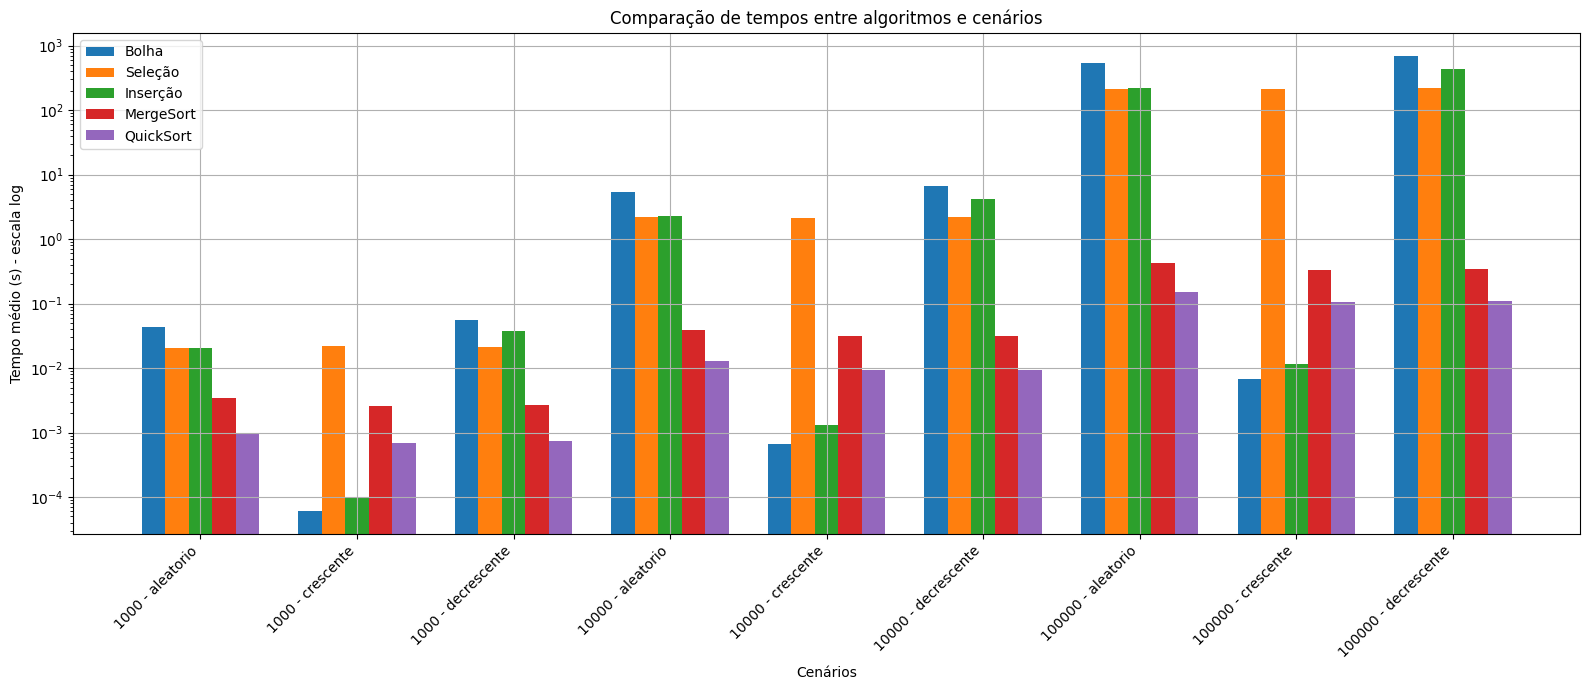

Gráfico salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\grafico_tempos_barras.png


In [12]:
df_plot = df_resultados.copy()
df_plot["Cenário"] = df_plot["Tamanho"].astype(str) + " - " + df_plot["Tipo de vetor"]

cenarios = list(df_plot["Cenário"].drop_duplicates())
algoritmos_plot = list(ALGORITMOS.keys())

x = np.arange(len(cenarios))
largura = 0.15

plt.figure(figsize=(16, 7))
for i, algoritmo in enumerate(algoritmos_plot):
    dados_alg = (
        df_plot[df_plot["Algoritmo"] == algoritmo]
        .set_index("Cenário")
        .reindex(cenarios)["Tempo médio (s)"]
        .values
    )
    plt.bar(x + i * largura, dados_alg, width=largura, label=algoritmo)

plt.xticks(x + largura * (len(algoritmos_plot) - 1) / 2, cenarios, rotation=45, ha="right")
plt.yscale("log")
plt.ylabel("Tempo médio (s) - escala log")
plt.xlabel("Cenários")
plt.title("Comparação de tempos entre algoritmos e cenários")
plt.legend()
plt.tight_layout()

grafico_barras_path = OUTPUT_DIR / "grafico_tempos_barras.png"
plt.savefig(grafico_barras_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {grafico_barras_path.resolve()}")

## 9. Gráficos de linha por tipo de vetor

Aqui o crescimento do tempo é analisado conforme aumenta o tamanho do vetor.  
Cada linha representa um algoritmo.

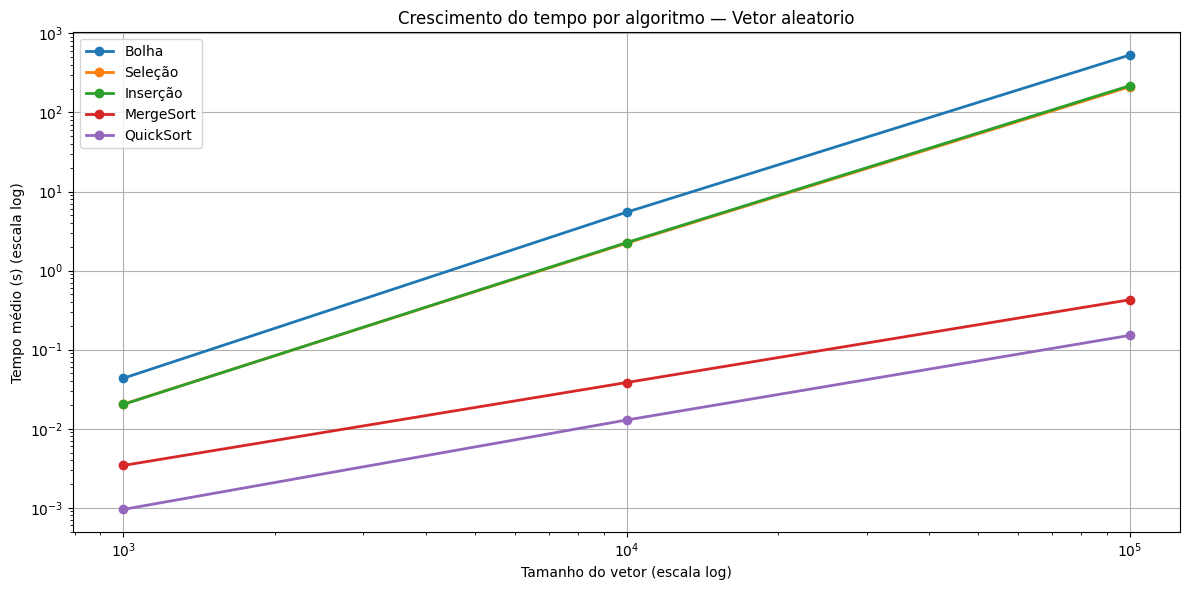

Gráfico salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\grafico_linhas_aleatorio.png


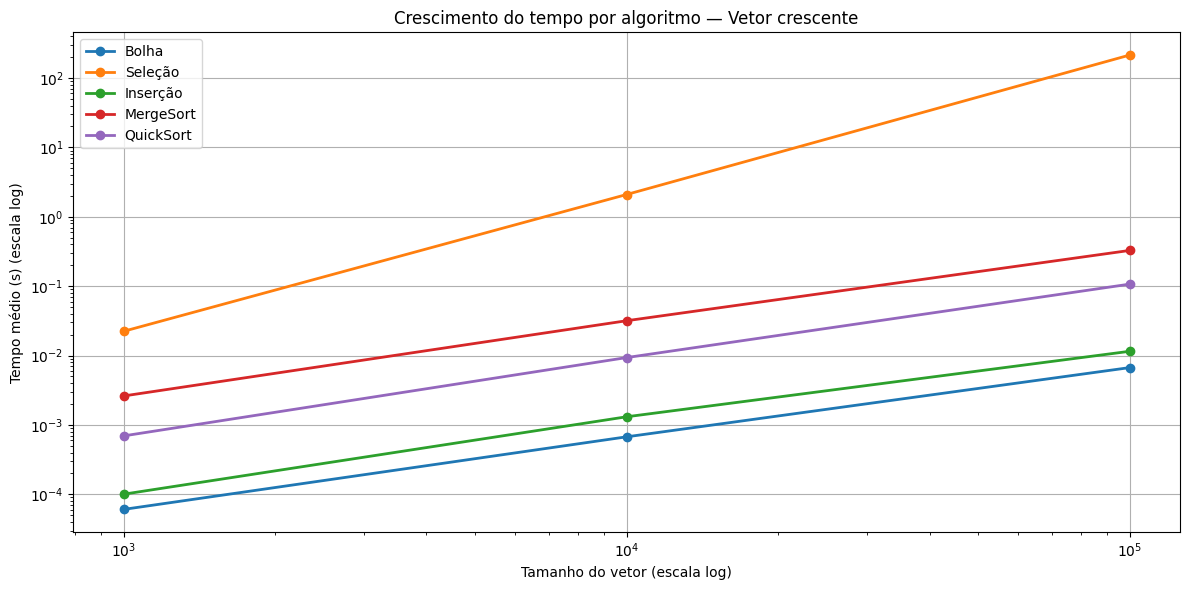

Gráfico salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\grafico_linhas_crescente.png


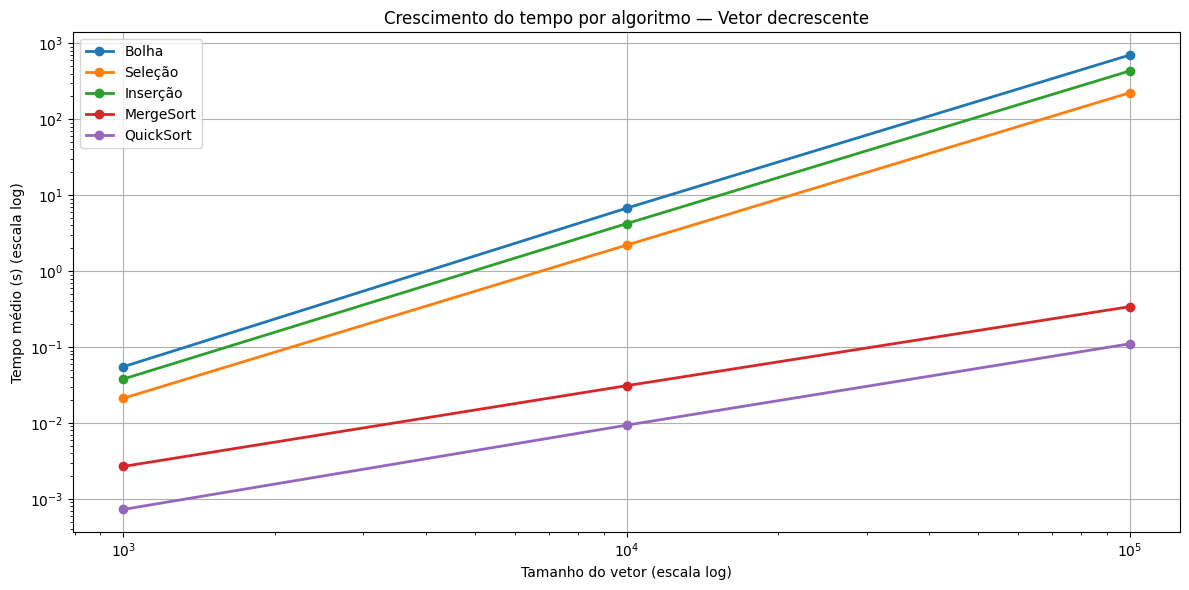

Gráfico salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\grafico_linhas_decrescente.png


In [13]:
for tipo in TIPOS_VETOR:
    plt.figure(figsize=(12, 6))
    df_tipo = df_resultados[df_resultados["Tipo de vetor"] == tipo].copy()

    for algoritmo in ALGORITMOS.keys():
        dados = (
            df_tipo[df_tipo["Algoritmo"] == algoritmo]
            .sort_values("Tamanho")
        )

        if dados.empty:
            continue

        plt.plot(
            dados["Tamanho"],
            dados["Tempo médio (s)"],
            marker="o",
            linewidth=2,
            label=algoritmo
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Tamanho do vetor (escala log)")
    plt.ylabel("Tempo médio (s) (escala log)")
    plt.title(f"Crescimento do tempo por algoritmo — Vetor {tipo}")
    plt.legend()
    plt.tight_layout()

    caminho = OUTPUT_DIR / f"grafico_linhas_{tipo}.png"
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Gráfico salvo em: {caminho.resolve()}")

## 10. Gráfico comparativo de memória

Embora o foco principal seja o tempo, este gráfico compara a memória de pico capturada durante as execuções.

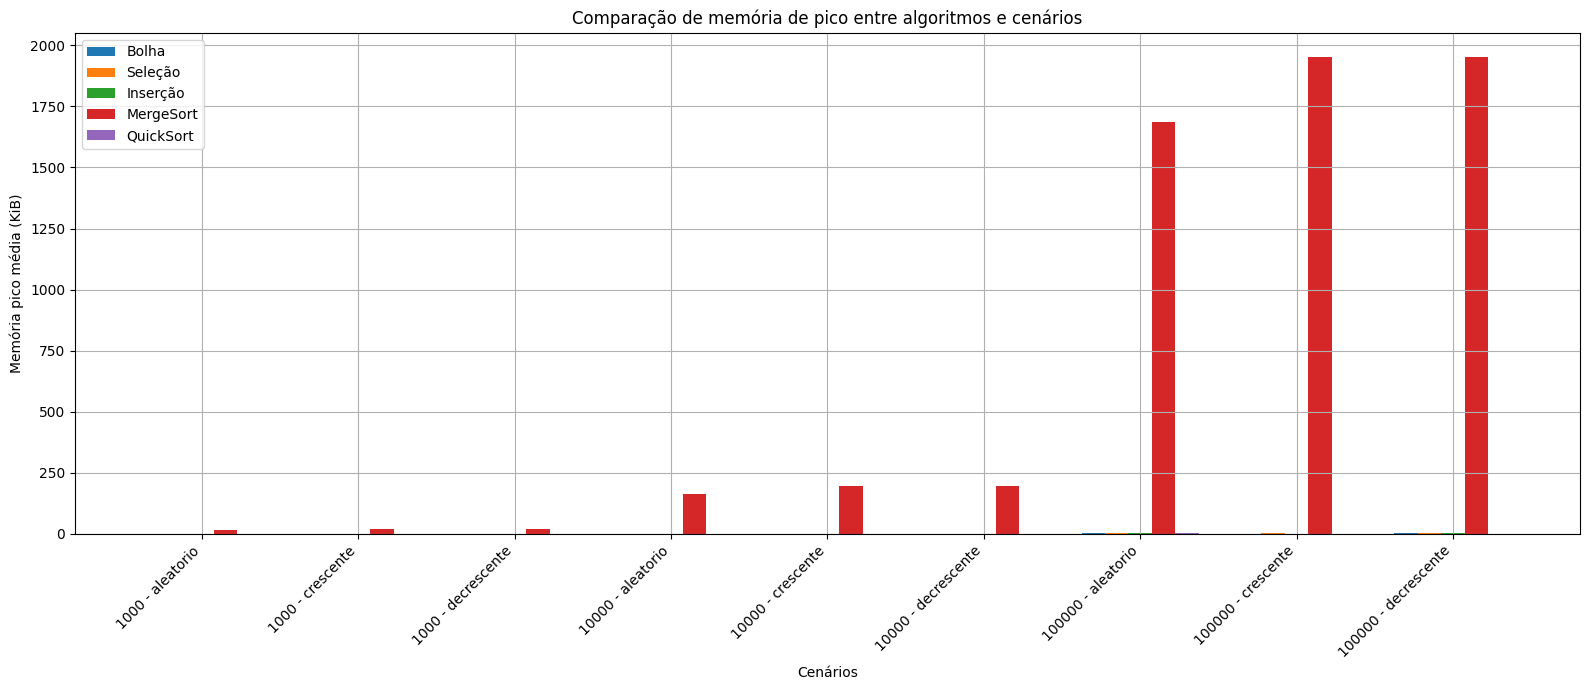

Gráfico salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\grafico_memoria_barras.png


In [14]:
df_plot_mem = df_resultados.copy()
df_plot_mem["Cenário"] = df_plot_mem["Tamanho"].astype(str) + " - " + df_plot_mem["Tipo de vetor"]

cenarios_mem = list(df_plot_mem["Cenário"].drop_duplicates())
algoritmos_mem = list(ALGORITMOS.keys())

x_mem = np.arange(len(cenarios_mem))
largura_mem = 0.15

plt.figure(figsize=(16, 7))
for i, algoritmo in enumerate(algoritmos_mem):
    dados_alg = (
        df_plot_mem[df_plot_mem["Algoritmo"] == algoritmo]
        .set_index("Cenário")
        .reindex(cenarios_mem)["Memória pico média (KiB)"]
        .values
    )
    plt.bar(x_mem + i * largura_mem, dados_alg, width=largura_mem, label=algoritmo)

plt.xticks(x_mem + largura_mem * (len(algoritmos_mem) - 1) / 2, cenarios_mem, rotation=45, ha="right")
plt.ylabel("Memória pico média (KiB)")
plt.xlabel("Cenários")
plt.title("Comparação de memória de pico entre algoritmos e cenários")
plt.legend()
plt.tight_layout()

grafico_memoria_path = OUTPUT_DIR / "grafico_memoria_barras.png"
plt.savefig(grafico_memoria_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {grafico_memoria_path.resolve()}")

## 11. Complexidade teórica dos algoritmos

A tabela abaixo resume a complexidade assintótica mais conhecida de cada algoritmo analisado.

In [15]:
df_complexidade = pd.DataFrame([
    {"Algoritmo": "Bolha", "Melhor caso": "O(n)", "Caso médio": "O(n²)", "Pior caso": "O(n²)", "Memória adicional": "O(1)"},
    {"Algoritmo": "Seleção", "Melhor caso": "O(n²)", "Caso médio": "O(n²)", "Pior caso": "O(n²)", "Memória adicional": "O(1)"},
    {"Algoritmo": "Inserção", "Melhor caso": "O(n)", "Caso médio": "O(n²)", "Pior caso": "O(n²)", "Memória adicional": "O(1)"},
    {"Algoritmo": "MergeSort", "Melhor caso": "O(n log n)", "Caso médio": "O(n log n)", "Pior caso": "O(n log n)", "Memória adicional": "O(n)"},
    {"Algoritmo": "QuickSort", "Melhor caso": "O(n log n)", "Caso médio": "O(n log n)", "Pior caso": "O(n²)", "Memória adicional": "O(log n) em média"},
])

display(df_complexidade)

,Algoritmo,Melhor caso,Caso médio,Pior caso,Memória adicional
0,Bolha,O(n),O(n²),O(n²),O(1)
1,Seleção,O(n²),O(n²),O(n²),O(1)
2,Inserção,O(n),O(n²),O(n²),O(1)
3,MergeSort,O(n log n),O(n log n),O(n log n),O(n)
4,QuickSort,O(n log n),O(n log n),O(n²),O(log n) em média


## 12. Crescimento empírico dos tempos

A ideia desta seção é comparar quanto o tempo realmente cresceu quando o tamanho do vetor aumentou em 10 vezes.

In [16]:
def calcular_fatores_crescimento(df):
    linhas = []

    for tipo in TIPOS_VETOR:
        for algoritmo in ALGORITMOS.keys():
            sub = (
                df[(df["Tipo de vetor"] == tipo) & (df["Algoritmo"] == algoritmo)]
                .sort_values("Tamanho")
            )

            if len(sub) >= 2:
                registro = {
                    "Tipo de vetor": tipo,
                    "Algoritmo": algoritmo,
                    "Fator 1k → 10k": np.nan,
                    "Fator 10k → 100k": np.nan,
                }

                if 1_000 in sub["Tamanho"].values and 10_000 in sub["Tamanho"].values:
                    t_1k = sub.loc[sub["Tamanho"] == 1_000, "Tempo médio (s)"].values[0]
                    t_10k = sub.loc[sub["Tamanho"] == 10_000, "Tempo médio (s)"].values[0]
                    registro["Fator 1k → 10k"] = t_10k / t_1k if t_1k > 0 else np.nan

                if 10_000 in sub["Tamanho"].values and 100_000 in sub["Tamanho"].values:
                    t_10k = sub.loc[sub["Tamanho"] == 10_000, "Tempo médio (s)"].values[0]
                    t_100k = sub.loc[sub["Tamanho"] == 100_000, "Tempo médio (s)"].values[0]
                    registro["Fator 10k → 100k"] = t_100k / t_10k if t_10k > 0 else np.nan

                linhas.append(registro)

    return pd.DataFrame(linhas)

df_crescimento = calcular_fatores_crescimento(df_resultados)
display(df_crescimento)

,Tipo de vetor,Algoritmo,Fator 1k → 10k,Fator 10k → 100k
0,aleatorio,Bolha,125.795972,97.222641
1,aleatorio,Seleção,108.563929,95.111277
2,aleatorio,Inserção,111.137743,96.425385
3,aleatorio,MergeSort,11.183501,11.131735
4,aleatorio,QuickSort,13.504090,11.759982
5,crescente,Bolha,11.120462,9.943612
6,crescente,Seleção,93.661286,102.264979
7,crescente,Inserção,13.059117,8.783551
8,crescente,MergeSort,12.146554,10.304327
9,crescente,QuickSort,13.457216,11.439927


## 13. Comparação entre média e mediana dos tempos

A comparação entre média e mediana ajuda a identificar **assimetria** e **instabilidade** nas medições. Quando os dois valores ficam muito distantes, isso pode indicar maior influência de oscilações do ambiente, aquecimento da máquina, carga do sistema ou efeitos de cache.


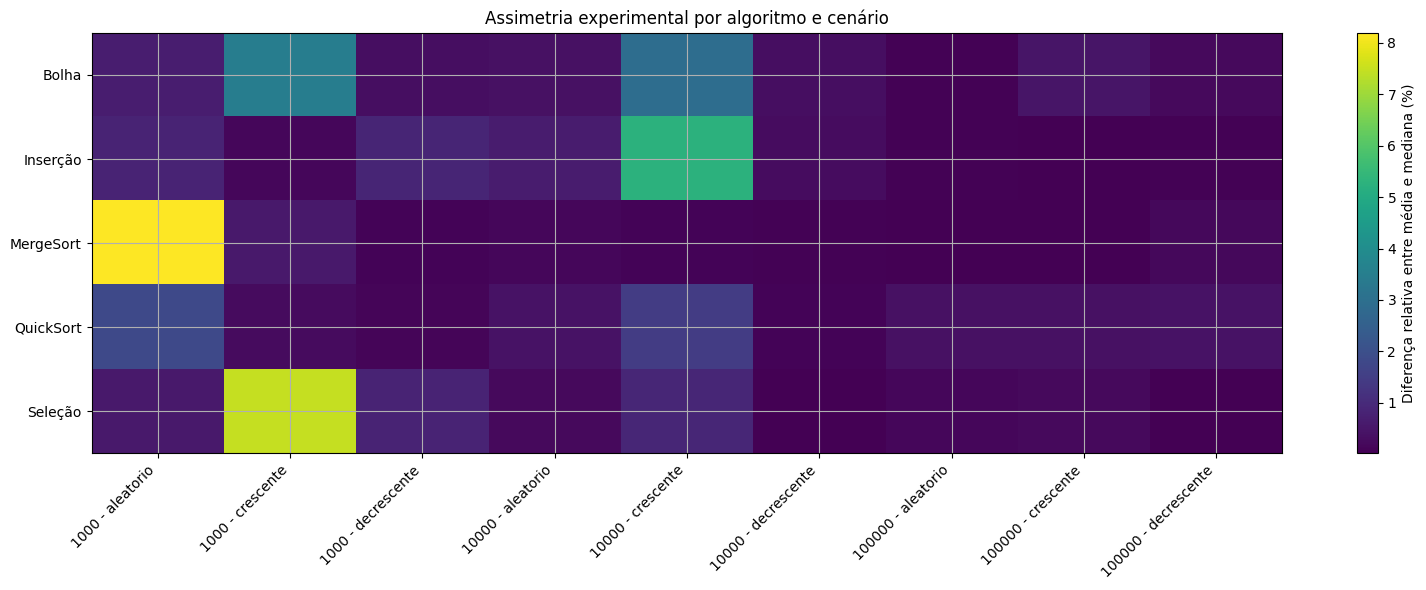

Heatmap salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\grafico_media_vs_mediana_heatmap.png


### Maiores diferenças entre média e mediana

,Tamanho,Tipo de vetor,Algoritmo,Tempo médio (s),Tempo mediano (s),Diferença absoluta (s),Diferença relativa (%),Cenário
1,1000,aleatorio,MergeSort,0.003431,0.003150,0.000281,8.196275,1000 - aleatorio
9,1000,crescente,Seleção,0.022346,0.020673,0.001672,7.483766,1000 - crescente
21,10000,crescente,Inserção,0.001311,0.001380,0.000069,5.279622,10000 - crescente
5,1000,crescente,Bolha,0.000061,0.000059,0.000002,3.465346,1000 - crescente
20,10000,crescente,Bolha,0.000674,0.000654,0.000020,2.952960,10000 - crescente
0,1000,aleatorio,QuickSort,0.000953,0.000936,0.000017,1.831912,1000 - aleatorio
22,10000,crescente,QuickSort,0.009347,0.009210,0.000137,1.463938,10000 - crescente
24,10000,crescente,Seleção,2.092927,2.074075,0.018852,0.900743,10000 - crescente
13,1000,decrescente,Inserção,0.037990,0.037668,0.000322,0.848120,1000 - decrescente
2,1000,aleatorio,Inserção,0.020311,0.020140,0.000171,0.839947,1000 - aleatorio


In [17]:
df_media_mediana = df_resultados[
    ["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)", "Tempo mediano (s)"]
].copy()

df_media_mediana["Diferença absoluta (s)"] = (
    df_media_mediana["Tempo médio (s)"] - df_media_mediana["Tempo mediano (s)"]
).abs()

df_media_mediana["Diferença relativa (%)"] = np.where(
    df_media_mediana["Tempo médio (s)"] > 0,
    (df_media_mediana["Diferença absoluta (s)"] / df_media_mediana["Tempo médio (s)"]) * 100,
    np.nan
)

df_media_mediana["Cenário"] = (
    df_media_mediana["Tamanho"].astype(str)
    + " - "
    + df_media_mediana["Tipo de vetor"]
)

df_mm_heat = df_media_mediana.pivot(
    index="Algoritmo",
    columns="Cenário",
    values="Diferença relativa (%)"
)

plt.figure(figsize=(16, 6))
plt.imshow(df_mm_heat.values, aspect="auto")
plt.xticks(range(len(df_mm_heat.columns)), df_mm_heat.columns, rotation=45, ha="right")
plt.yticks(range(len(df_mm_heat.index)), df_mm_heat.index)
plt.colorbar(label="Diferença relativa entre média e mediana (%)")
plt.title("Assimetria experimental por algoritmo e cenário")
plt.tight_layout()

caminho_heat = OUTPUT_DIR / "grafico_media_vs_mediana_heatmap.png"
plt.savefig(caminho_heat, dpi=150, bbox_inches="tight")
plt.show()

print(f"Heatmap salvo em: {caminho_heat.resolve()}")

display(Markdown("### Maiores diferenças entre média e mediana"))
display(
    df_media_mediana.sort_values("Diferença relativa (%)", ascending=False).head(15)
)


## 14. Visualizações interativas com Plotly

Além dos gráficos em Matplotlib, esta seção cria gráficos interativos em **Plotly**, facilitando a exploração dos resultados com zoom, hover, filtros visuais e exportação em HTML.


In [18]:
if not PLOTLY_DISPONIVEL:
    display(Markdown(
        "**Plotly não está instalado neste ambiente.** "
        "Para ativar os gráficos interativos, instale a biblioteca com `!pip install plotly`."
    ))
else:
    df_plotly = df_resultados.copy()
    df_plotly["Cenário"] = (
        df_plotly["Tamanho"].astype(str)
        + " - "
        + df_plotly["Tipo de vetor"]
    )

    fig_bar = px.bar(
        df_plotly,
        x="Algoritmo",
        y="Tempo médio (s)",
        color="Algoritmo",
        facet_col="Tipo de vetor",
        animation_frame="Tamanho",
        log_y=True,
        title="Comparação interativa dos tempos médios por algoritmo"
    )
    fig_bar.update_layout(height=600)
    fig_bar.show()

    caminho_html = OUTPUT_DIR / "plotly_tempos_medios_interativo.html"
    fig_bar.write_html(str(caminho_html))
    print(f"Gráfico interativo salvo em: {caminho_html.resolve()}")

    fig_line = px.line(
        df_plotly.sort_values("Tamanho"),
        x="Tamanho",
        y="Tempo médio (s)",
        color="Algoritmo",
        line_dash="Tipo de vetor",
        markers=True,
        log_x=True,
        log_y=True,
        title="Crescimento interativo do tempo por algoritmo e tipo de vetor",
        hover_data=["Memória pico média (KiB)", "Tempo mediano (s)", "Clock médio (MHz)"]
    )
    fig_line.update_layout(height=600)
    fig_line.show()

    caminho_html = OUTPUT_DIR / "plotly_crescimento_tempos_interativo.html"
    fig_line.write_html(str(caminho_html))
    print(f"Gráfico interativo salvo em: {caminho_html.resolve()}")

    fig_scatter = px.scatter(
        df_plotly,
        x="Tempo médio (s)",
        y="Memória pico média (KiB)",
        color="Algoritmo",
        symbol="Tipo de vetor",
        size="Tamanho",
        log_x=True,
        title="Tempo médio versus memória de pico média",
        hover_data=["Cenário", "Tempo mediano (s)", "Clock médio (MHz)"]
    )
    fig_scatter.update_layout(height=600)
    fig_scatter.show()

    caminho_html = OUTPUT_DIR / "plotly_tempo_vs_memoria_interativo.html"
    fig_scatter.write_html(str(caminho_html))
    print(f"Gráfico interativo salvo em: {caminho_html.resolve()}")


Gráfico interativo salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\plotly_tempos_medios_interativo.html


Gráfico interativo salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\plotly_crescimento_tempos_interativo.html


Gráfico interativo salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\plotly_tempo_vs_memoria_interativo.html


In [19]:
if not PLOTLY_DISPONIVEL:
    display(Markdown(
        "**Plotly não está instalado neste ambiente.** "
        "Para ativar os boxplots interativos, instale a biblioteca com `!pip install plotly`."
    ))
else:
    df_box_plotly = df_tentativas.copy()

    fig_box = px.box(
        df_box_plotly,
        x="Algoritmo",
        y="Tempo (s)",
        color="Algoritmo",
        facet_col="Tipo de vetor",
        animation_frame="Tamanho",
        points="all",
        log_y=True,
        title="Boxplots interativos por repetição"
    )
    fig_box.update_layout(height=650)
    fig_box.show()

    caminho_html = OUTPUT_DIR / "plotly_boxplots_repeticoes_interativo.html"
    fig_box.write_html(str(caminho_html))
    print(f"Gráfico interativo salvo em: {caminho_html.resolve()}")

    df_rank_heat = df_resultados.copy()
    df_rank_heat["Cenário"] = (
        df_rank_heat["Tamanho"].astype(str)
        + " - "
        + df_rank_heat["Tipo de vetor"]
    )
    df_rank_heat["Ranking"] = (
        df_rank_heat.groupby("Cenário")["Tempo médio (s)"]
        .rank(method="dense", ascending=True)
    )

    tabela_heat = df_rank_heat.pivot(index="Algoritmo", columns="Cenário", values="Ranking")

    fig_heat = px.imshow(
        tabela_heat,
        text_auto=True,
        aspect="auto",
        title="Heatmap interativo de ranking por cenário"
    )
    fig_heat.update_layout(height=500)
    fig_heat.show()

    caminho_html = OUTPUT_DIR / "plotly_heatmap_ranking_interativo.html"
    fig_heat.write_html(str(caminho_html))
    print(f"Gráfico interativo salvo em: {caminho_html.resolve()}")


Gráfico interativo salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\plotly_boxplots_repeticoes_interativo.html


Gráfico interativo salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\plotly_heatmap_ranking_interativo.html


## 15. Exportação do notebook para HTML ou PDF

A célula abaixo ajuda a exportar o próprio notebook para **HTML** e **PDF** usando `nbconvert`. O formato HTML costuma funcionar com menos dependências. Já o PDF pode exigir instalação de componentes adicionais, como uma distribuição LaTeX no Windows.


In [21]:
# NOTEBOOK_PATH = None
# Exemplo:
NOTEBOOK_PATH = Path(r"C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\projeto1_benchmark_ordenacao_vDesktop.ipynb")

def localizar_notebook():
    if NOTEBOOK_PATH is not None:
        return Path(NOTEBOOK_PATH)

    candidatos = sorted(Path.cwd().glob("*.ipynb"))
    if candidatos:
        return candidatos[0]

    raise FileNotFoundError(
        "Não foi possível localizar automaticamente o notebook. "
        "Defina a variável NOTEBOOK_PATH com o caminho completo do arquivo .ipynb."
    )

def exportar_notebook(formatos=("html", "pdf")):
    notebook_path = localizar_notebook()

    for formato in formatos:
        comando = [
            sys.executable,
            "-m",
            "jupyter",
            "nbconvert",
            "--to",
            formato,
            str(notebook_path),
            "--output-dir",
            str(OUTPUT_DIR)
        ]

        print(f"\nTentando exportar para {formato.upper()}...")
        resultado = subprocess.run(comando, capture_output=True, text=True)

        if resultado.returncode == 0:
            print(f"Exportação para {formato.upper()} concluída com sucesso.")
        else:
            print(f"Falha ao exportar para {formato.upper()}.")
            if resultado.stderr:
                print(resultado.stderr[:2000])

            if formato == "pdf":
                print(
                    "Dica: no Windows, a exportação para PDF pode exigir uma distribuição LaTeX "
                    "(por exemplo, MiKTeX ou TeX Live). Se preferir, exporte primeiro para HTML."
                )

# Para executar:
exportar_notebook(("html", "pdf"))
# ou apenas:
# exportar_notebook(("html",))



Tentando exportar para HTML...
Falha ao exportar para HTML.
[NbConvertApp] WARNING | pattern 'C:\\Users\\matpa\\Documents\\Mestrado - ComputaÃ§Ã£o Aplicada\\Algoritmos e ProgramaÃ§Ã£o\\Projeto 1\\projeto1_benchmark_ordenacao_vDesktop.ipynb' matched no files


Tentando exportar para PDF...
Falha ao exportar para PDF.
[NbConvertApp] WARNING | pattern 'C:\\Users\\matpa\\Documents\\Mestrado - ComputaÃ§Ã£o Aplicada\\Algoritmos e ProgramaÃ§Ã£o\\Projeto 1\\projeto1_benchmark_ordenacao_vDesktop.ipynb' matched no files

Dica: no Windows, a exportação para PDF pode exigir uma distribuição LaTeX (por exemplo, MiKTeX ou TeX Live). Se preferir, exporte primeiro para HTML.


## 16. Geração automática de análise crítica


In [23]:
# Melhor algoritmo por cenário
idx_melhores = df_resultados.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"].idxmin()
df_melhores = df_resultados.loc[idx_melhores, ["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)"]]

# Pior algoritmo por cenário
idx_piores = df_resultados.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"].idxmax()
df_piores = df_resultados.loc[idx_piores, ["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)"]]

# Ranking médio global
df_aux = df_resultados.copy()
df_aux["Ranking"] = df_aux.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"].rank(method="dense", ascending=True)
ranking_medio = (
    df_aux.groupby("Algoritmo")["Ranking"]
    .mean()
    .sort_values()
)

equipamento_txt = []
for _, row in df_maquina.iterrows():
    equipamento_txt.append(f"- **{row['Métrica']}**: {row['Valor']}")

melhores_txt = []
for _, row in df_melhores.sort_values(["Tamanho", "Tipo de vetor"]).iterrows():
    melhores_txt.append(
        f"- No cenário **{row['Tamanho']:,} / {row['Tipo de vetor']}**, o algoritmo mais rápido foi **{row['Algoritmo']}** "
        f"com tempo médio de **{row['Tempo médio (s)']:.6f} s**."
    )

piores_txt = []
for _, row in df_piores.sort_values(["Tamanho", "Tipo de vetor"]).iterrows():
    piores_txt.append(
        f"- No cenário **{row['Tamanho']:,} / {row['Tipo de vetor']}**, o algoritmo mais lento foi **{row['Algoritmo']}** "
        f"com tempo médio de **{row['Tempo médio (s)']:.6f} s**."
    )

ranking_txt = []
for algoritmo, valor in ranking_medio.items():
    ranking_txt.append(f"- **{algoritmo}**: ranking médio = **{valor:.2f}**")

analise_md = f"""
## Texto-base para o relatório

### Metodologia
Os experimentos foram realizados em Python, utilizando implementações próprias dos algoritmos de ordenação **Bolha**, **Seleção**, **Inserção**, **MergeSort** e **QuickSort**. A massa de dados foi composta por vetores com **1.000**, **10.000** e **100.000** elementos. Para cada tamanho, foi gerado inicialmente um vetor aleatório e, a partir dele, foram produzidas também versões em ordem crescente e decrescente, garantindo comparabilidade entre os cenários. **Cada experimento foi repetido 3 vezes para reduzir oscilações do ambiente de execução**. Além disso, o notebook armazenou o resultado de cada tentativa individual e utilizou o **tempo médio** das 5 execuções como métrica principal para comparação entre os algoritmos. As métricas coletadas incluíram **tempo de execução**, **memória de pico** durante a ordenação e, quando disponível no sistema, o **clock do processador**. Além das tabelas-resumo, foram produzidos gráficos estáticos em **Matplotlib** e gráficos interativos em **Plotly**, incluindo comparações de tempos, memória, boxplots por repetição, comparação entre média e mediana e visualizações de apoio à interpretação dos resultados.

### Equipamento utilizado
{"\n".join(equipamento_txt)}

### Principais resultados observados
{"\n".join(melhores_txt)}

### Cenários mais críticos
{"\n".join(piores_txt)}

### Ranking médio dos algoritmos
{"\n".join(ranking_txt)}

### Análise crítica sobre a eficiência dos algoritmos
De forma geral, os algoritmos de complexidade quadrática tenderam a apresentar crescimento muito mais acentuado do tempo conforme o tamanho da entrada aumentou, principalmente nos vetores maiores. Já os algoritmos **MergeSort** e **QuickSort**, cuja complexidade média é da ordem de **O(n log n)**, tendem a manter desempenho mais adequado em entradas grandes, mostrando-se mais escaláveis para massas de dados extensas. Além disso, algoritmos como **Inserção** podem se beneficiar de vetores já quase ordenados, o que ajuda a explicar possíveis diferenças de desempenho entre os tipos de entrada.

### Análise crítica: assintótica versus tempos obtidos
Os resultados empíricos tendem a confirmar a teoria assintótica, mas não de forma absolutamente idêntica. Isso ocorre porque a análise assintótica descreve o comportamento de crescimento para entradas grandes, abstraindo constantes multiplicativas, otimizações de implementação, alocação de memória, cache, arquitetura do processador e estado inicial dos dados. Assim, é esperado que dois algoritmos com a mesma classe assintótica apresentem tempos diferentes na prática, e também que certos algoritmos apresentem desempenho melhor ou pior em cenários específicos, dependendo da organização inicial do vetor. O uso de 5 repetições por cenário contribui para reduzir ruídos experimentais e torna a comparação mais estável do que uma medição isolada. Os boxplots, a comparação entre média e mediana e os testes estatísticos exploratórios ajudam a verificar se as diferenças observadas são consistentes também sob a ótica da variabilidade experimental.
"""

display(Markdown(analise_md))



## Texto-base para o relatório

### Metodologia
Os experimentos foram realizados em Python, utilizando implementações próprias dos algoritmos de ordenação **Bolha**, **Seleção**, **Inserção**, **MergeSort** e **QuickSort**. A massa de dados foi composta por vetores com **1.000**, **10.000** e **100.000** elementos. Para cada tamanho, foi gerado inicialmente um vetor aleatório e, a partir dele, foram produzidas também versões em ordem crescente e decrescente, garantindo comparabilidade entre os cenários. **Cada experimento foi repetido 3 vezes para reduzir oscilações do ambiente de execução**. Além disso, o notebook armazenou o resultado de cada tentativa individual e utilizou o **tempo médio** das 5 execuções como métrica principal para comparação entre os algoritmos. As métricas coletadas incluíram **tempo de execução**, **memória de pico** durante a ordenação e, quando disponível no sistema, o **clock do processador**. Além das tabelas-resumo, foram produzidos gráficos estáticos em **Matplotlib** e gráficos interativos em **Plotly**, incluindo comparações de tempos, memória, boxplots por repetição, comparação entre média e mediana e visualizações de apoio à interpretação dos resultados.

### Equipamento utilizado
- **Sistema Operacional**: Windows-11-10.0.26200-SP0
- **Arquitetura**: AMD64
- **Processador**: AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD
- **Python**: 3.14.3
- **Núcleos físicos**: 8
- **Núcleos lógicos**: 16
- **RAM total (GB)**: 15.92
- **Clock atual (MHz)**: 3801.0
- **Clock mínimo (MHz)**: 0.0
- **Clock máximo (MHz)**: 3801.0

### Principais resultados observados
- No cenário **1,000 / aleatorio**, o algoritmo mais rápido foi **QuickSort** com tempo médio de **0.000953 s**.
- No cenário **1,000 / crescente**, o algoritmo mais rápido foi **Bolha** com tempo médio de **0.000061 s**.
- No cenário **1,000 / decrescente**, o algoritmo mais rápido foi **QuickSort** com tempo médio de **0.000728 s**.
- No cenário **10,000 / aleatorio**, o algoritmo mais rápido foi **QuickSort** com tempo médio de **0.012876 s**.
- No cenário **10,000 / crescente**, o algoritmo mais rápido foi **Bolha** com tempo médio de **0.000674 s**.
- No cenário **10,000 / decrescente**, o algoritmo mais rápido foi **QuickSort** com tempo médio de **0.009360 s**.
- No cenário **100,000 / aleatorio**, o algoritmo mais rápido foi **QuickSort** com tempo médio de **0.151418 s**.
- No cenário **100,000 / crescente**, o algoritmo mais rápido foi **Bolha** com tempo médio de **0.006701 s**.
- No cenário **100,000 / decrescente**, o algoritmo mais rápido foi **QuickSort** com tempo médio de **0.110432 s**.

### Cenários mais críticos
- No cenário **1,000 / aleatorio**, o algoritmo mais lento foi **Bolha** com tempo médio de **0.043483 s**.
- No cenário **1,000 / crescente**, o algoritmo mais lento foi **Seleção** com tempo médio de **0.022346 s**.
- No cenário **1,000 / decrescente**, o algoritmo mais lento foi **Bolha** com tempo médio de **0.055164 s**.
- No cenário **10,000 / aleatorio**, o algoritmo mais lento foi **Bolha** com tempo médio de **5.469944 s**.
- No cenário **10,000 / crescente**, o algoritmo mais lento foi **Seleção** com tempo médio de **2.092927 s**.
- No cenário **10,000 / decrescente**, o algoritmo mais lento foi **Bolha** com tempo médio de **6.750990 s**.
- No cenário **100,000 / aleatorio**, o algoritmo mais lento foi **Bolha** com tempo médio de **531.802434 s**.
- No cenário **100,000 / crescente**, o algoritmo mais lento foi **Seleção** com tempo médio de **214.033137 s**.
- No cenário **100,000 / decrescente**, o algoritmo mais lento foi **Bolha** com tempo médio de **701.240944 s**.

### Ranking médio dos algoritmos
- **QuickSort**: ranking médio = **1.67**
- **MergeSort**: ranking médio = **2.67**
- **Inserção**: ranking médio = **3.22**
- **Bolha**: ranking médio = **3.67**
- **Seleção**: ranking médio = **3.78**

### Análise crítica sobre a eficiência dos algoritmos
De forma geral, os algoritmos de complexidade quadrática tenderam a apresentar crescimento muito mais acentuado do tempo conforme o tamanho da entrada aumentou, principalmente nos vetores maiores. Já os algoritmos **MergeSort** e **QuickSort**, cuja complexidade média é da ordem de **O(n log n)**, tendem a manter desempenho mais adequado em entradas grandes, mostrando-se mais escaláveis para massas de dados extensas. Além disso, algoritmos como **Inserção** podem se beneficiar de vetores já quase ordenados, o que ajuda a explicar possíveis diferenças de desempenho entre os tipos de entrada.

### Análise crítica: assintótica versus tempos obtidos
Os resultados empíricos tendem a confirmar a teoria assintótica, mas não de forma absolutamente idêntica. Isso ocorre porque a análise assintótica descreve o comportamento de crescimento para entradas grandes, abstraindo constantes multiplicativas, otimizações de implementação, alocação de memória, cache, arquitetura do processador e estado inicial dos dados. Assim, é esperado que dois algoritmos com a mesma classe assintótica apresentem tempos diferentes na prática, e também que certos algoritmos apresentem desempenho melhor ou pior em cenários específicos, dependendo da organização inicial do vetor. O uso de 5 repetições por cenário contribui para reduzir ruídos experimentais e torna a comparação mais estável do que uma medição isolada. Os boxplots, a comparação entre média e mediana e os testes estatísticos exploratórios ajudam a verificar se as diferenças observadas são consistentes também sob a ótica da variabilidade experimental.


## 16. Conclusão

Após a execução completa do notebook, você terá:

- uma base consolidada em CSV com os **resultados resumidos por cenário**
- uma base em CSV com os **resultados detalhados de cada tentativa**
- gráficos estáticos em **Matplotlib**
- gráficos interativos em **Plotly**
- boxplots por repetição
- comparação entre **média** e **mediana**
- testes estatísticos simples entre algoritmos em cada cenário
- uma análise crítica inicial gerada automaticamente
- funções prontas para exportação do notebook em **HTML** e **PDF**

Todos os resultados principais são salvos na pasta configurada no início do notebook. No Windows, o caminho padrão definido é:

`C:\Users\matpa\OneDrive\Documentos\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados`


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import HTML, display
import plotly.express as px
import plotly.io as pio

# ==========================================
# CONFIGURAÇÃO
# ==========================================
PASTA_RESULTADOS = Path(r"C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados")

ARQ_RESUMO = PASTA_RESULTADOS / "resultados_benchmark_ordenacao_resumo.csv"
ARQ_TENTATIVAS = PASTA_RESULTADOS / "resultados_benchmark_ordenacao_tentativas.csv"
ARQ_DASHBOARD = PASTA_RESULTADOS / "dashboard_benchmark_unificado.html"

# ==========================================
# LEITURA DOS DADOS JÁ GERADOS
# ==========================================
df_resultados = pd.read_csv(ARQ_RESUMO, encoding="utf-8-sig")
df_tentativas = pd.read_csv(ARQ_TENTATIVAS, encoding="utf-8-sig")

# Padronização
df_resultados["Cenário"] = df_resultados["Tamanho"].astype(str) + " - " + df_resultados["Tipo de vetor"]
df_tentativas["Cenário"] = df_tentativas["Tamanho"].astype(str) + " - " + df_tentativas["Tipo de vetor"]

# ==========================================
# INDICADORES DERIVADOS
# ==========================================
# Ranking por cenário
df_rank = df_resultados.copy()
df_rank["Ranking"] = (
    df_rank.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# Melhor algoritmo por cenário
idx_best = df_resultados.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"].idxmin()
df_best = (
    df_resultados.loc[idx_best, ["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)"]]
    .sort_values(["Tamanho", "Tipo de vetor"])
    .reset_index(drop=True)
)

# Ranking global médio
df_rank_global = (
    df_rank.groupby("Algoritmo", as_index=False)["Ranking"]
    .mean()
    .rename(columns={"Ranking": "Ranking médio"})
    .sort_values("Ranking médio")
)

# Média x mediana
df_mm = df_resultados[["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)", "Tempo mediano (s)"]].copy()
df_mm["Diferença absoluta (s)"] = (df_mm["Tempo médio (s)"] - df_mm["Tempo mediano (s)"]).abs()
df_mm["Diferença relativa (%)"] = np.where(
    df_mm["Tempo médio (s)"] > 0,
    (df_mm["Diferença absoluta (s)"] / df_mm["Tempo médio (s)"]) * 100,
    np.nan
)
df_mm["Cenário"] = df_mm["Tamanho"].astype(str) + " - " + df_mm["Tipo de vetor"]

# Fatores de crescimento
def calcular_fatores_crescimento(df):
    linhas = []
    tipos = sorted(df["Tipo de vetor"].unique())
    algoritmos = sorted(df["Algoritmo"].unique())

    for tipo in tipos:
        for algoritmo in algoritmos:
            sub = (
                df[(df["Tipo de vetor"] == tipo) & (df["Algoritmo"] == algoritmo)]
                .sort_values("Tamanho")
            )

            registro = {
                "Tipo de vetor": tipo,
                "Algoritmo": algoritmo,
                "Fator 1k → 10k": np.nan,
                "Fator 10k → 100k": np.nan,
            }

            if 1000 in sub["Tamanho"].values and 10000 in sub["Tamanho"].values:
                t_1k = sub.loc[sub["Tamanho"] == 1000, "Tempo médio (s)"].values[0]
                t_10k = sub.loc[sub["Tamanho"] == 10000, "Tempo médio (s)"].values[0]
                registro["Fator 1k → 10k"] = t_10k / t_1k if t_1k > 0 else np.nan

            if 10000 in sub["Tamanho"].values and 100000 in sub["Tamanho"].values:
                t_10k = sub.loc[sub["Tamanho"] == 10000, "Tempo médio (s)"].values[0]
                t_100k = sub.loc[sub["Tamanho"] == 100000, "Tempo médio (s)"].values[0]
                registro["Fator 10k → 100k"] = t_100k / t_10k if t_10k > 0 else np.nan

            linhas.append(registro)

    return pd.DataFrame(linhas)

df_crescimento = calcular_fatores_crescimento(df_resultados)

# Heatmaps
heat_rank = df_rank.pivot(index="Algoritmo", columns="Cenário", values="Ranking")
heat_mm = df_mm.pivot(index="Algoritmo", columns="Cenário", values="Diferença relativa (%)")

# Grupo de complexidade
alg_quadraticos = ["Bolha", "Seleção", "Inserção"]
df_resultados["Grupo"] = np.where(df_resultados["Algoritmo"].isin(alg_quadraticos), "Quadráticos", "O(n log n)")

# ==========================================
# KPIs
# ==========================================
qtd_cenarios = df_resultados[["Tamanho", "Tipo de vetor"]].drop_duplicates().shape[0]
qtd_algoritmos = df_resultados["Algoritmo"].nunique()
qtd_repeticoes = df_tentativas["Execução"].nunique()
melhor_global = df_rank_global.iloc[0]["Algoritmo"]
pior_global = df_rank_global.iloc[-1]["Algoritmo"]
tempo_min = df_resultados["Tempo médio (s)"].min()
tempo_max = df_resultados["Tempo médio (s)"].max()

# ==========================================
# GRÁFICOS
# ==========================================
fig_bar = px.bar(
    df_resultados.sort_values(["Tamanho", "Tipo de vetor", "Tempo médio (s)"]),
    x="Algoritmo",
    y="Tempo médio (s)",
    color="Algoritmo",
    facet_col="Tipo de vetor",
    animation_frame="Tamanho",
    log_y=True,
    title="Tempos médios por algoritmo",
    hover_data=["Tempo mediano (s)", "Memória pico média (KiB)"]
)
fig_bar.update_layout(height=600)

fig_line = px.line(
    df_resultados.sort_values("Tamanho"),
    x="Tamanho",
    y="Tempo médio (s)",
    color="Algoritmo",
    facet_col="Tipo de vetor",
    markers=True,
    log_x=True,
    log_y=True,
    title="Crescimento do tempo por tamanho do vetor"
)
fig_line.update_layout(height=550)

fig_box = px.box(
    df_tentativas,
    x="Algoritmo",
    y="Tempo (s)",
    color="Algoritmo",
    facet_col="Tipo de vetor",
    animation_frame="Tamanho",
    points="all",
    log_y=True,
    title="Distribuição dos tempos por repetição",
    hover_data=["Execução", "Memória pico (KiB)", "Ordenado corretamente"]
)
fig_box.update_layout(height=650)

fig_rank = px.imshow(
    heat_rank,
    text_auto=True,
    aspect="auto",
    title="Ranking por cenário (1 = melhor)"
)
fig_rank.update_layout(height=450)

fig_mm = px.imshow(
    heat_mm,
    text_auto=".2f",
    aspect="auto",
    title="Diferença relativa entre média e mediana (%)"
)
fig_mm.update_layout(height=450)

fig_scatter = px.scatter(
    df_resultados,
    x="Tempo médio (s)",
    y="Memória pico média (KiB)",
    color="Algoritmo",
    symbol="Tipo de vetor",
    size="Tamanho",
    log_x=True,
    title="Tempo médio vs memória pico média",
    hover_data=["Tempo mediano (s)"]
)
fig_scatter.update_layout(height=500)

fig_group = px.line(
    df_resultados.sort_values("Tamanho"),
    x="Tamanho",
    y="Tempo médio (s)",
    color="Algoritmo",
    facet_col="Grupo",
    facet_row="Tipo de vetor",
    markers=True,
    log_x=True,
    log_y=True,
    title="Comparação por grupo de complexidade"
)
fig_group.update_layout(height=900)

df_crescimento_long = df_crescimento.melt(
    id_vars=["Tipo de vetor", "Algoritmo"],
    value_vars=["Fator 1k → 10k", "Fator 10k → 100k"],
    var_name="Transição",
    value_name="Fator"
)
fig_growth = px.bar(
    df_crescimento_long,
    x="Algoritmo",
    y="Fator",
    color="Transição",
    facet_col="Tipo de vetor",
    barmode="group",
    title="Fatores de crescimento"
)
fig_growth.update_layout(height=500)

# ==========================================
# TABELAS HTML
# ==========================================
html_best = df_best.to_html(index=False, border=0, classes="table")
html_rank = df_rank_global.round(3).to_html(index=False, border=0, classes="table")
html_growth = df_crescimento.round(3).to_html(index=False, border=0, classes="table")

# ==========================================
# CONVERSÃO DOS GRÁFICOS
# ==========================================
fig_bar_html = pio.to_html(fig_bar, full_html=False, include_plotlyjs="cdn")
fig_line_html = pio.to_html(fig_line, full_html=False, include_plotlyjs=False)
fig_box_html = pio.to_html(fig_box, full_html=False, include_plotlyjs=False)
fig_rank_html = pio.to_html(fig_rank, full_html=False, include_plotlyjs=False)
fig_mm_html = pio.to_html(fig_mm, full_html=False, include_plotlyjs=False)
fig_scatter_html = pio.to_html(fig_scatter, full_html=False, include_plotlyjs=False)
fig_group_html = pio.to_html(fig_group, full_html=False, include_plotlyjs=False)
fig_growth_html = pio.to_html(fig_growth, full_html=False, include_plotlyjs=False)

# ==========================================
# HTML FINAL
# ==========================================
html_final = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
    <meta charset="UTF-8">
    <title>Dashboard Benchmark de Ordenação</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        body {{
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1f2937;
        }}
        .container {{
            width: min(1450px, 95%);
            margin: 24px auto;
        }}
        .header {{
            background: linear-gradient(135deg, #1e3a8a, #2563eb);
            color: white;
            padding: 24px;
            border-radius: 18px;
            margin-bottom: 24px;
        }}
        .header h1 {{
            margin: 0 0 8px 0;
        }}
        .grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
            gap: 16px;
            margin-bottom: 24px;
        }}
        .card {{
            background: white;
            border-radius: 16px;
            padding: 18px;
            box-shadow: 0 8px 24px rgba(0,0,0,0.08);
        }}
        .kpi-title {{
            font-size: 12px;
            color: #6b7280;
            text-transform: uppercase;
            margin-bottom: 8px;
        }}
        .kpi-value {{
            font-size: 28px;
            font-weight: bold;
        }}
        .section {{
            margin-bottom: 24px;
        }}
        .section h2 {{
            margin-top: 0;
        }}
        .two-cols {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 18px;
        }}
        .table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 14px;
        }}
        .table th, .table td {{
            padding: 10px 12px;
            border-bottom: 1px solid #e5e7eb;
            text-align: left;
        }}
        .table th {{
            background: #eff6ff;
        }}
        @media (max-width: 980px) {{
            .two-cols {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>Dashboard — Benchmark de Algoritmos de Ordenação</h1>
            <p>Dashboard montado a partir dos CSVs já gerados no experimento, sem rerodar os algoritmos.</p>
        </div>

        <div class="grid">
            <div class="card"><div class="kpi-title">Cenários</div><div class="kpi-value">{qtd_cenarios}</div></div>
            <div class="card"><div class="kpi-title">Algoritmos</div><div class="kpi-value">{qtd_algoritmos}</div></div>
            <div class="card"><div class="kpi-title">Repetições</div><div class="kpi-value">{qtd_repeticoes}</div></div>
            <div class="card"><div class="kpi-title">Melhor ranking global</div><div class="kpi-value">{melhor_global}</div></div>
            <div class="card"><div class="kpi-title">Pior ranking global</div><div class="kpi-value">{pior_global}</div></div>
            <div class="card"><div class="kpi-title">Faixa de tempo médio</div><div class="kpi-value">{tempo_min:.6f} s → {tempo_max:.2f} s</div></div>
        </div>

        <div class="section card">
            <h2>Tempos médios por algoritmo</h2>
            {fig_bar_html}
        </div>

        <div class="section card">
            <h2>Crescimento do tempo</h2>
            {fig_line_html}
        </div>

        <div class="section card">
            <h2>Boxplots por repetição</h2>
            {fig_box_html}
        </div>

        <div class="section card">
            <h2>Comparação por grupo de complexidade</h2>
            {fig_group_html}
        </div>

        <div class="section two-cols">
            <div class="card">
                <h2>Ranking por cenário</h2>
                {fig_rank_html}
            </div>
            <div class="card">
                <h2>Média vs mediana</h2>
                {fig_mm_html}
            </div>
        </div>

        <div class="section card">
            <h2>Tempo vs memória</h2>
            {fig_scatter_html}
        </div>

        <div class="section card">
            <h2>Fatores de crescimento</h2>
            {fig_growth_html}
        </div>

        <div class="section two-cols">
            <div class="card">
                <h2>Melhores algoritmos por cenário</h2>
                {html_best}
            </div>
            <div class="card">
                <h2>Ranking global médio</h2>
                {html_rank}
            </div>
        </div>

        <div class="section card">
            <h2>Tabela de fatores de crescimento</h2>
            {html_growth}
        </div>
    </div>
</body>
</html>
"""

ARQ_DASHBOARD.write_text(html_final, encoding="utf-8")

print(f"Dashboard salvo em: {ARQ_DASHBOARD}")
display(HTML(f'<a href="{ARQ_DASHBOARD.as_uri()}" target="_blank">Abrir dashboard HTML</a>'))

Dashboard salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\dashboard_benchmark_unificado.html


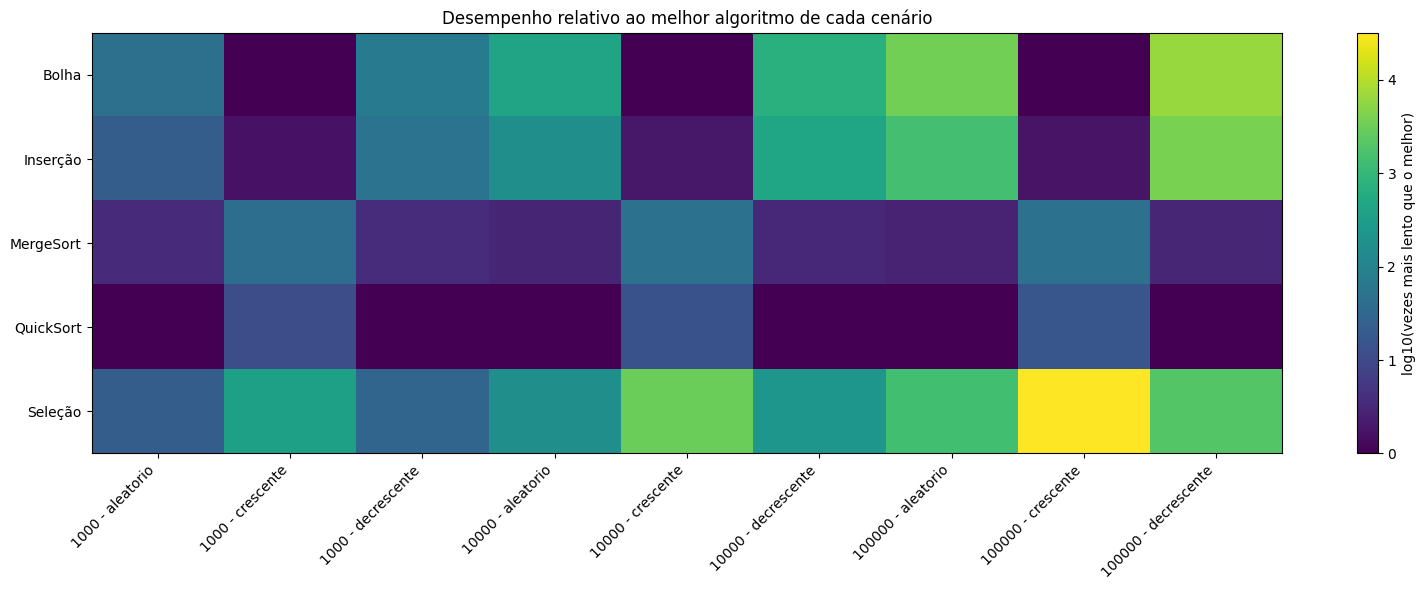

,Tamanho,Tipo de vetor,Algoritmo,Tempo médio (s),Vezes mais lento que o melhor
0,1000,aleatorio,QuickSort,0.000953,1.000000
1,1000,aleatorio,MergeSort,0.003431,3.598692
2,1000,aleatorio,Inserção,0.020311,21.302056
3,1000,aleatorio,Seleção,0.020431,21.427702
4,1000,aleatorio,Bolha,0.043483,45.604811
5,1000,crescente,Bolha,0.000061,1.000000
6,1000,crescente,Inserção,0.000100,1.656216
7,1000,crescente,QuickSort,0.000695,11.461496
8,1000,crescente,MergeSort,0.002613,43.124862
9,1000,crescente,Seleção,0.022346,368.740924


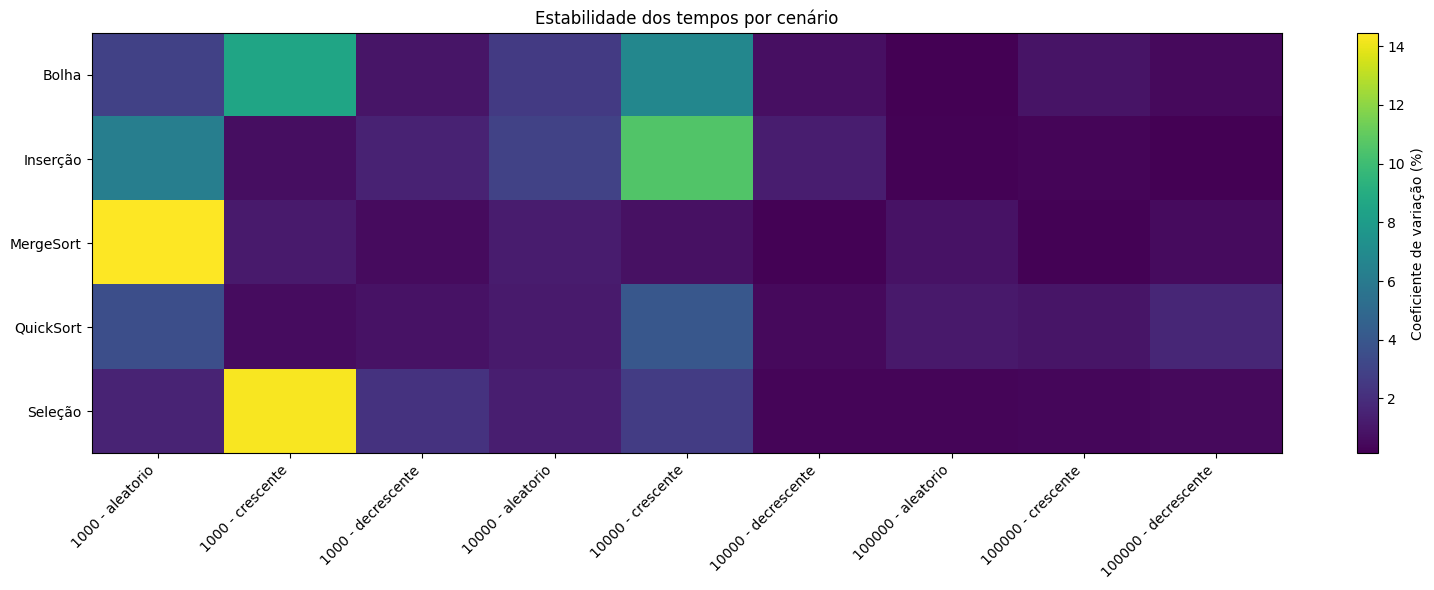

,Tamanho,Tipo de vetor,Algoritmo,CV (%)
4,1000,aleatorio,Seleção,1.535317
0,1000,aleatorio,Bolha,2.893719
3,1000,aleatorio,QuickSort,3.561264
1,1000,aleatorio,Inserção,6.258812
2,1000,aleatorio,MergeSort,14.454572
8,1000,crescente,QuickSort,0.598722
6,1000,crescente,Inserção,0.663400
7,1000,crescente,MergeSort,1.140319
5,1000,crescente,Bolha,8.547473
9,1000,crescente,Seleção,14.314973


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# =========================================================
# 1) HEATMAP — QUANTAS VEZES MAIS LENTO QUE O MELHOR DO CENÁRIO
# =========================================================
df_rel = df_resultados.copy()
df_rel["Cenário"] = df_rel["Tamanho"].astype(str) + " - " + df_rel["Tipo de vetor"]

melhor_por_cenario = df_rel.groupby("Cenário")["Tempo médio (s)"].transform("min")
df_rel["Vezes mais lento que o melhor"] = df_rel["Tempo médio (s)"] / melhor_por_cenario

heat_rel = df_rel.pivot(
    index="Algoritmo",
    columns="Cenário",
    values="Vezes mais lento que o melhor"
)

plt.figure(figsize=(16, 6))
plt.imshow(np.log10(heat_rel.values), aspect="auto")
plt.xticks(range(len(heat_rel.columns)), heat_rel.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_rel.index)), heat_rel.index)
plt.colorbar(label="log10(vezes mais lento que o melhor)")
plt.title("Desempenho relativo ao melhor algoritmo de cada cenário")
plt.tight_layout()
plt.show()

display(
    df_rel[["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)", "Vezes mais lento que o melhor"]]
    .sort_values(["Tamanho", "Tipo de vetor", "Vezes mais lento que o melhor"])
)

# =========================================================
# 2) HEATMAP — ESTABILIDADE DAS REPETIÇÕES (COEFICIENTE DE VARIAÇÃO)
# =========================================================
df_cv = (
    df_tentativas
    .groupby(["Tamanho", "Tipo de vetor", "Algoritmo"])["Tempo (s)"]
    .agg(["mean", "std"])
    .reset_index()
)

df_cv["CV (%)"] = np.where(df_cv["mean"] > 0, (df_cv["std"] / df_cv["mean"]) * 100, np.nan)
df_cv["Cenário"] = df_cv["Tamanho"].astype(str) + " - " + df_cv["Tipo de vetor"]

heat_cv = df_cv.pivot(
    index="Algoritmo",
    columns="Cenário",
    values="CV (%)"
)

plt.figure(figsize=(16, 6))
plt.imshow(heat_cv.values, aspect="auto")
plt.xticks(range(len(heat_cv.columns)), heat_cv.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_cv.index)), heat_cv.index)
plt.colorbar(label="Coeficiente de variação (%)")
plt.title("Estabilidade dos tempos por cenário")
plt.tight_layout()
plt.show()

display(
    df_cv[["Tamanho", "Tipo de vetor", "Algoritmo", "CV (%)"]]
    .sort_values(["Tamanho", "Tipo de vetor", "CV (%)"])
)

# =========================================================
# 3) VERSÃO INTERATIVA EM PLOTLY — TEMPO RELATIVO AO MELHOR
# =========================================================
fig_rel = px.imshow(
    heat_rel,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Quantas vezes cada algoritmo foi mais lento que o melhor do cenário"
)
fig_rel.update_layout(height=500)
fig_rel.show()

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import HTML, display
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# =========================================================
# DASHBOARD UNIFICADO SEM HEATMAP E SEM BOXPLOT
# Requer: df_resultados e df_tentativas já existentes
# =========================================================

# -----------------------------
# 1) Configuração de saída
# -----------------------------
if "PASTA_RESULTADOS" in globals():
    output_dir = Path(PASTA_RESULTADOS)
elif "OUTPUT_DIR" in globals():
    output_dir = Path(OUTPUT_DIR)
else:
    output_dir = Path.cwd()

output_dir.mkdir(parents=True, exist_ok=True)
dashboard_path = output_dir / "dashboard_benchmark_sem_heatmap.html"

# -----------------------------
# 2) Preparação dos dados
# -----------------------------
df_res = df_resultados.copy()
df_tent = df_tentativas.copy()

df_res["Cenário"] = df_res["Tamanho"].astype(str) + " - " + df_res["Tipo de vetor"]
df_tent["Cenário"] = df_tent["Tamanho"].astype(str) + " - " + df_tent["Tipo de vetor"]

alg_quadraticos = ["Bolha", "Seleção", "Inserção"]
df_res["Grupo"] = np.where(df_res["Algoritmo"].isin(alg_quadraticos), "Quadráticos", "O(n log n)")

# Ranking por cenário
df_rank = df_res.copy()
df_rank["Ranking"] = (
    df_rank.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# Melhor algoritmo por cenário
idx_best = df_res.groupby(["Tamanho", "Tipo de vetor"])["Tempo médio (s)"].idxmin()
df_best = (
    df_res.loc[idx_best, ["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)"]]
    .sort_values(["Tamanho", "Tipo de vetor"])
    .reset_index(drop=True)
)

# Ranking global médio
df_rank_global = (
    df_rank.groupby("Algoritmo", as_index=False)["Ranking"]
    .mean()
    .rename(columns={"Ranking": "Ranking médio"})
    .sort_values("Ranking médio")
)

# Tempo relativo ao melhor cenário
df_rel = df_res.copy()
melhor_por_cenario = df_rel.groupby("Cenário")["Tempo médio (s)"].transform("min")
df_rel["Vezes mais lento que o melhor"] = df_rel["Tempo médio (s)"] / melhor_por_cenario
df_rel["log10_relativo"] = np.log10(df_rel["Vezes mais lento que o melhor"])

# Estabilidade: coeficiente de variação
df_cv = (
    df_tent.groupby(["Tamanho", "Tipo de vetor", "Algoritmo"])["Tempo (s)"]
    .agg(["mean", "std"])
    .reset_index()
)
df_cv["CV (%)"] = np.where(df_cv["mean"] > 0, (df_cv["std"] / df_cv["mean"]) * 100, np.nan)
df_cv["Cenário"] = df_cv["Tamanho"].astype(str) + " - " + df_cv["Tipo de vetor"]

# Média vs mediana
df_mm = df_res[["Tamanho", "Tipo de vetor", "Algoritmo", "Tempo médio (s)", "Tempo mediano (s)"]].copy()
df_mm["Diferença absoluta (s)"] = (df_mm["Tempo médio (s)"] - df_mm["Tempo mediano (s)"]).abs()
df_mm["Diferença relativa (%)"] = np.where(
    df_mm["Tempo médio (s)"] > 0,
    (df_mm["Diferença absoluta (s)"] / df_mm["Tempo médio (s)"]) * 100,
    np.nan
)
df_mm["Cenário"] = df_mm["Tamanho"].astype(str) + " - " + df_mm["Tipo de vetor"]

# Fatores de crescimento
def calcular_fatores_crescimento(df):
    linhas = []
    for tipo in sorted(df["Tipo de vetor"].unique()):
        for algoritmo in sorted(df["Algoritmo"].unique()):
            sub = (
                df[(df["Tipo de vetor"] == tipo) & (df["Algoritmo"] == algoritmo)]
                .sort_values("Tamanho")
            )

            registro = {
                "Tipo de vetor": tipo,
                "Algoritmo": algoritmo,
                "Fator 1k → 10k": np.nan,
                "Fator 10k → 100k": np.nan,
            }

            if 1000 in sub["Tamanho"].values and 10000 in sub["Tamanho"].values:
                t_1k = sub.loc[sub["Tamanho"] == 1000, "Tempo médio (s)"].values[0]
                t_10k = sub.loc[sub["Tamanho"] == 10000, "Tempo médio (s)"].values[0]
                registro["Fator 1k → 10k"] = t_10k / t_1k if t_1k > 0 else np.nan

            if 10000 in sub["Tamanho"].values and 100000 in sub["Tamanho"].values:
                t_10k = sub.loc[sub["Tamanho"] == 10000, "Tempo médio (s)"].values[0]
                t_100k = sub.loc[sub["Tamanho"] == 100000, "Tempo médio (s)"].values[0]
                registro["Fator 10k → 100k"] = t_100k / t_10k if t_10k > 0 else np.nan

            linhas.append(registro)

    return pd.DataFrame(linhas)

df_crescimento = calcular_fatores_crescimento(df_res)

# KPIs
qtd_cenarios = df_res[["Tamanho", "Tipo de vetor"]].drop_duplicates().shape[0]
qtd_algoritmos = df_res["Algoritmo"].nunique()
qtd_repeticoes = df_tent["Execução"].nunique() if "Execução" in df_tent.columns else np.nan
melhor_global = df_rank_global.iloc[0]["Algoritmo"]
pior_global = df_rank_global.iloc[-1]["Algoritmo"]
tempo_min = df_res["Tempo médio (s)"].min()
tempo_max = df_res["Tempo médio (s)"].max()

# -----------------------------
# 3) Gráficos
# -----------------------------

# A. Barras de tempo médio
fig_bar = px.bar(
    df_res.sort_values(["Tamanho", "Tipo de vetor", "Tempo médio (s)"]),
    x="Algoritmo",
    y="Tempo médio (s)",
    color="Algoritmo",
    facet_col="Tipo de vetor",
    animation_frame="Tamanho",
    log_y=True,
    title="Tempos médios por algoritmo",
    hover_data=["Tempo mediano (s)", "Memória pico média (KiB)"]
)
fig_bar.update_layout(height=600, margin=dict(l=20, r=20, t=60, b=20))

# B. Crescimento por tamanho
fig_line = px.line(
    df_res.sort_values("Tamanho"),
    x="Tamanho",
    y="Tempo médio (s)",
    color="Algoritmo",
    facet_col="Tipo de vetor",
    markers=True,
    log_x=True,
    log_y=True,
    title="Crescimento do tempo por tamanho do vetor",
    hover_data=["Tempo mediano (s)", "Memória pico média (KiB)"]
)
fig_line.update_layout(height=550, margin=dict(l=20, r=20, t=60, b=20))

# C. Separação por grupo de complexidade
fig_group = px.line(
    df_res.sort_values("Tamanho"),
    x="Tamanho",
    y="Tempo médio (s)",
    color="Algoritmo",
    facet_col="Grupo",
    facet_row="Tipo de vetor",
    markers=True,
    log_x=True,
    log_y=True,
    title="Comparação por grupo de complexidade",
    hover_data=["Tempo mediano (s)"]
)
fig_group.update_layout(height=900, margin=dict(l=20, r=20, t=60, b=20))

# D. Bubble chart: vezes mais lento que o melhor
fig_rel = px.scatter(
    df_rel.sort_values(["Tamanho", "Tipo de vetor", "Vezes mais lento que o melhor"]),
    x="Cenário",
    y="Algoritmo",
    size="Vezes mais lento que o melhor",
    color="log10_relativo",
    hover_data=["Tempo médio (s)", "Vezes mais lento que o melhor", "Tamanho", "Tipo de vetor"],
    title="Desempenho relativo ao melhor algoritmo de cada cenário",
    labels={"log10_relativo": "log10(vezes mais lento)"}
)
fig_rel.update_layout(height=520, margin=dict(l=20, r=20, t=60, b=20))
fig_rel.update_xaxes(tickangle=35)

# E. Ranking global médio
fig_rank = px.bar(
    df_rank_global.sort_values("Ranking médio", ascending=False),
    x="Ranking médio",
    y="Algoritmo",
    orientation="h",
    text="Ranking médio",
    title="Ranking médio global dos algoritmos"
)
fig_rank.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig_rank.update_layout(height=420, margin=dict(l=20, r=40, t=60, b=20))

# F. Estabilidade das repetições (CV %)
fig_cv = px.bar(
    df_cv.sort_values(["Tamanho", "Tipo de vetor", "CV (%)"]),
    x="Algoritmo",
    y="CV (%)",
    color="Algoritmo",
    facet_col="Tipo de vetor",
    animation_frame="Tamanho",
    barmode="group",
    title="Estabilidade dos tempos por repetição (Coeficiente de variação %)",
    hover_data=["mean", "std"]
)
fig_cv.update_layout(height=600, margin=dict(l=20, r=20, t=60, b=20))

# G. Média vs mediana
fig_mm = px.scatter(
    df_mm,
    x="Tempo médio (s)",
    y="Tempo mediano (s)",
    color="Algoritmo",
    symbol="Tipo de vetor",
    size="Tamanho",
    log_x=True,
    log_y=True,
    hover_data=["Diferença relativa (%)"],
    title="Comparação entre tempo médio e tempo mediano"
)

lim_inf = min(df_mm["Tempo médio (s)"].min(), df_mm["Tempo mediano (s)"].min())
lim_sup = max(df_mm["Tempo médio (s)"].max(), df_mm["Tempo mediano (s)"].max())

fig_mm.add_trace(
    go.Scatter(
        x=[lim_inf, lim_sup],
        y=[lim_inf, lim_sup],
        mode="lines",
        name="Linha média = mediana",
        line=dict(dash="dash")
    )
)
fig_mm.update_layout(height=500, margin=dict(l=20, r=20, t=60, b=20))

# H. Tempo vs memória
fig_scatter = px.scatter(
    df_res,
    x="Tempo médio (s)",
    y="Memória pico média (KiB)",
    color="Algoritmo",
    symbol="Tipo de vetor",
    size="Tamanho",
    log_x=True,
    title="Tempo médio versus memória pico média",
    hover_data=["Tempo mediano (s)"]
)
fig_scatter.update_layout(height=500, margin=dict(l=20, r=20, t=60, b=20))

# I. Fatores de crescimento
df_cresc_long = df_crescimento.melt(
    id_vars=["Tipo de vetor", "Algoritmo"],
    value_vars=["Fator 1k → 10k", "Fator 10k → 100k"],
    var_name="Transição",
    value_name="Fator"
)

fig_growth = px.bar(
    df_cresc_long,
    x="Algoritmo",
    y="Fator",
    color="Transição",
    facet_col="Tipo de vetor",
    barmode="group",
    title="Fatores de crescimento do tempo"
)
fig_growth.update_layout(height=520, margin=dict(l=20, r=20, t=60, b=20))

# -----------------------------
# 4) Tabelas HTML
# -----------------------------
html_best = df_best.to_html(index=False, border=0, classes="table")
html_rank = df_rank_global.round(3).to_html(index=False, border=0, classes="table")
html_growth = df_crescimento.round(3).to_html(index=False, border=0, classes="table")

# -----------------------------
# 5) HTML dos gráficos
# -----------------------------
fig_bar_html = pio.to_html(fig_bar, full_html=False, include_plotlyjs="cdn")
fig_line_html = pio.to_html(fig_line, full_html=False, include_plotlyjs=False)
fig_group_html = pio.to_html(fig_group, full_html=False, include_plotlyjs=False)
fig_rel_html = pio.to_html(fig_rel, full_html=False, include_plotlyjs=False)
fig_rank_html = pio.to_html(fig_rank, full_html=False, include_plotlyjs=False)
fig_cv_html = pio.to_html(fig_cv, full_html=False, include_plotlyjs=False)
fig_mm_html = pio.to_html(fig_mm, full_html=False, include_plotlyjs=False)
fig_scatter_html = pio.to_html(fig_scatter, full_html=False, include_plotlyjs=False)
fig_growth_html = pio.to_html(fig_growth, full_html=False, include_plotlyjs=False)

# -----------------------------
# 6) HTML final
# -----------------------------
html_final = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
    <meta charset="UTF-8">
    <title>Dashboard Benchmark de Ordenação</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        body {{
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1f2937;
        }}
        .container {{
            width: min(1450px, 95%);
            margin: 24px auto;
        }}
        .header {{
            background: linear-gradient(135deg, #1e3a8a, #2563eb);
            color: white;
            padding: 24px;
            border-radius: 18px;
            margin-bottom: 24px;
        }}
        .header h1 {{
            margin: 0 0 8px 0;
        }}
        .grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
            gap: 16px;
            margin-bottom: 24px;
        }}
        .card {{
            background: white;
            border-radius: 16px;
            padding: 18px;
            box-shadow: 0 8px 24px rgba(0,0,0,0.08);
        }}
        .kpi-title {{
            font-size: 12px;
            color: #6b7280;
            text-transform: uppercase;
            margin-bottom: 8px;
        }}
        .kpi-value {{
            font-size: 28px;
            font-weight: bold;
        }}
        .section {{
            margin-bottom: 24px;
        }}
        .section h2 {{
            margin-top: 0;
        }}
        .two-cols {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 18px;
        }}
        .table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 14px;
        }}
        .table th, .table td {{
            padding: 10px 12px;
            border-bottom: 1px solid #e5e7eb;
            text-align: left;
        }}
        .table th {{
            background: #eff6ff;
        }}
        @media (max-width: 980px) {{
            .two-cols {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>Dashboard — Benchmark de Algoritmos de Ordenação</h1>
            <p>
                Painel unificado com foco em comparação de desempenho, estabilidade e crescimento,
                sem heatmaps e sem boxplots.
            </p>
        </div>

        <div class="grid">
            <div class="card"><div class="kpi-title">Cenários</div><div class="kpi-value">{qtd_cenarios}</div></div>
            <div class="card"><div class="kpi-title">Algoritmos</div><div class="kpi-value">{qtd_algoritmos}</div></div>
            <div class="card"><div class="kpi-title">Repetições</div><div class="kpi-value">{qtd_repeticoes}</div></div>
            <div class="card"><div class="kpi-title">Melhor ranking global</div><div class="kpi-value">{melhor_global}</div></div>
            <div class="card"><div class="kpi-title">Pior ranking global</div><div class="kpi-value">{pior_global}</div></div>
            <div class="card"><div class="kpi-title">Faixa de tempo médio</div><div class="kpi-value">{tempo_min:.6f} s → {tempo_max:.2f} s</div></div>
        </div>

        <div class="section card">
            <h2>Tempos médios por algoritmo</h2>
            {fig_bar_html}
        </div>

        <div class="section card">
            <h2>Crescimento do tempo por tamanho do vetor</h2>
            {fig_line_html}
        </div>

        <div class="section card">
            <h2>Comparação por grupo de complexidade</h2>
            {fig_group_html}
        </div>

        <div class="section card">
            <h2>Desempenho relativo ao melhor do cenário</h2>
            {fig_rel_html}
        </div>

        <div class="section two-cols">
            <div class="card">
                <h2>Ranking médio global</h2>
                {fig_rank_html}
            </div>
            <div class="card">
                <h2>Estabilidade das repetições (CV %)</h2>
                {fig_cv_html}
            </div>
        </div>

        <div class="section two-cols">
            <div class="card">
                <h2>Média versus mediana</h2>
                {fig_mm_html}
            </div>
            <div class="card">
                <h2>Tempo versus memória</h2>
                {fig_scatter_html}
            </div>
        </div>

        <div class="section card">
            <h2>Fatores de crescimento</h2>
            {fig_growth_html}
        </div>

        <div class="section two-cols">
            <div class="card">
                <h2>Melhores algoritmos por cenário</h2>
                {html_best}
            </div>
            <div class="card">
                <h2>Ranking global médio</h2>
                {html_rank}
            </div>
        </div>

        <div class="section card">
            <h2>Tabela de fatores de crescimento</h2>
            {html_growth}
        </div>
    </div>
</body>
</html>
"""

dashboard_path.write_text(html_final, encoding="utf-8")

print(f"Dashboard salvo em: {dashboard_path}")
display(HTML(f'<a href="{dashboard_path.as_uri()}" target="_blank">Abrir dashboard HTML</a>'))

Dashboard salvo em: C:\Users\matpa\Documents\Mestrado - Computação Aplicada\Algoritmos e Programação\Projeto 1\Resultados\dashboard_benchmark_sem_heatmap.html
